# GraphRAG for Legal Document Analysis and Summarization
### Research Implementation Notebook

Authors:
Snehashish Das, Gungun Sharma, Sruti Mishra

Project:
MCA Final Year Project

Objective:
Develop a Graph Retrieval-Augmented Generation (GraphRAG) framework for
legal document understanding by integrating semantic retrieval,
knowledge graphs, and citation-aware summarization.

Pipeline:

PDFs
→ Extraction
→ Cleaning
→ Metadata
→ Chunking
→ Embeddings
→ FAISS
→ Hybrid Retrieval
→ GraphRAG
→ Evaluation

Notebook Version:
Research Edition v2.0

### SECTION 0 | CELL 2
**IMPORT LIBRARIES**

In [1]:
import os
import re
import gc
import json
import time
import random
import pickle
import warnings

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import nltk
import torch

warnings.filterwarnings("ignore")

nltk.download("punkt")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("="*70)
print("DEVICE :", DEVICE)

if DEVICE=="cuda":
    print("GPU :", torch.cuda.get_device_name(0))

print("="*70)

DEVICE : cuda
GPU : NVIDIA GeForce RTX 3050


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Snehashish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### SECTION 0 | CELL 3
**GLOBAL CONFIGURATION**

In [2]:
CONFIG = {

    # Dataset
    "DATASET_NAME": "Indian Legal Judgments",

    # Chunking
    "CHUNK_SIZE": 250,
    "CHUNK_OVERLAP": 60,

    # Retrieval
    "TOP_K": 5,

    # Embedding Models
    "EMBEDDING_MODELS": [

        "sentence-transformers/all-MiniLM-L6-v2",

        "law-ai/InLegalBERT",

        "nlpaueb/legal-bert-base-uncased"

    ],

    # Random Seed
    "SEED": 42,

    # OCR Threshold
    "OCR_THRESHOLD": 500,

    # Maximum Tokens
    "MAX_TOKENS": 512

}

random.seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])
torch.manual_seed(CONFIG["SEED"])

print(json.dumps(CONFIG, indent=4))

{
    "DATASET_NAME": "Indian Legal Judgments",
    "CHUNK_SIZE": 250,
    "CHUNK_OVERLAP": 60,
    "TOP_K": 5,
    "EMBEDDING_MODELS": [
        "sentence-transformers/all-MiniLM-L6-v2",
        "law-ai/InLegalBERT",
        "nlpaueb/legal-bert-base-uncased"
    ],
    "SEED": 42,
    "OCR_THRESHOLD": 500,
    "MAX_TOKENS": 512
}


### SECTION 0 | CELL 4
**CREATE PROJECT DIRECTORY STRUCTURE**

In [3]:
BASE_PATH = Path.cwd()

PROJECT_DIRS = {

    "raw_pdfs"      : BASE_PATH/"data"/"raw_pdfs",

    "extracted"     : BASE_PATH/"data"/"extracted_text",

    "cleaned"       : BASE_PATH/"data"/"cleaned_text",

    "metadata"      : BASE_PATH/"data"/"metadata",

    "chunks"        : BASE_PATH/"data"/"chunks",

    "embeddings"    : BASE_PATH/"data"/"embeddings",

    "faiss"         : BASE_PATH/"data"/"faiss",

    "bm25"          : BASE_PATH/"data"/"bm25",

    "retrieval"     : BASE_PATH/"data"/"retrieval",

    "neo4j"         : BASE_PATH/"data"/"neo4j",

    "summaries"     : BASE_PATH/"data"/"summaries",

    "evaluation"    : BASE_PATH/"data"/"evaluation",

    "cache"         : BASE_PATH/"data"/"cache",

    "results"       : BASE_PATH/"results",

    "figures"       : BASE_PATH/"figures",

    "logs"          : BASE_PATH/"logs"
}

for folder in PROJECT_DIRS.values():

    folder.mkdir(parents=True, exist_ok=True)

print("="*70)
print("PROJECT STRUCTURE CREATED")
print("="*70)

for name, path in PROJECT_DIRS.items():

    print(f"{name:<15} : {path}")

PROJECT STRUCTURE CREATED
raw_pdfs        : e:\Legal Finale\data\raw_pdfs
extracted       : e:\Legal Finale\data\extracted_text
cleaned         : e:\Legal Finale\data\cleaned_text
metadata        : e:\Legal Finale\data\metadata
chunks          : e:\Legal Finale\data\chunks
embeddings      : e:\Legal Finale\data\embeddings
faiss           : e:\Legal Finale\data\faiss
bm25            : e:\Legal Finale\data\bm25
retrieval       : e:\Legal Finale\data\retrieval
neo4j           : e:\Legal Finale\data\neo4j
summaries       : e:\Legal Finale\data\summaries
evaluation      : e:\Legal Finale\data\evaluation
cache           : e:\Legal Finale\data\cache
results         : e:\Legal Finale\results
figures         : e:\Legal Finale\figures
logs            : e:\Legal Finale\logs


### SECTION 1 | CELL 5
**DATASET DISCOVERY**

In [4]:
import pandas as pd
from pathlib import Path

RAW_PDF_PATH = PROJECT_DIRS["raw_pdfs"]

pdf_files = sorted(
    set(
        list(RAW_PDF_PATH.glob("*.pdf")) +
        list(RAW_PDF_PATH.glob("*.PDF"))
    ),
    key=lambda p: p.name.lower()
)

print("=" * 80)
print("DATASET DISCOVERY")
print("=" * 80)

print(f"Total PDF Files Found : {len(pdf_files)}")

if len(pdf_files) == 0:
    raise FileNotFoundError(
        "No PDF files found inside data/raw_pdfs/"
    )

dataset_df = pd.DataFrame({

    "Document_ID": range(1, len(pdf_files)+1),

    "File_Name": [pdf.name for pdf in pdf_files],

    "File_Size_MB": [
        round(pdf.stat().st_size/(1024*1024),2)
        for pdf in pdf_files
    ]
})

display(dataset_df.head())

print("\nDataset Ready")

DATASET DISCOVERY
Total PDF Files Found : 150


,Document_ID,File_Name,File_Size_MB
0,1,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,0.31
1,2,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,0.31
2,3,Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...,0.26
3,4,Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...,0.27
4,5,Copy of Agartala_Municipal_Corporation_vs_Smt_...,0.33



Dataset Ready


### SECTION 1 | CELL 6
**DATASET STATISTICS**

In [5]:
print("="*80)
print("DATASET STATISTICS")
print("="*80)

print(f"Total Documents      : {len(dataset_df)}")

print(f"Average File Size    : {dataset_df['File_Size_MB'].mean():.2f} MB")

print(f"Largest File         : {dataset_df['File_Size_MB'].max():.2f} MB")

print(f"Smallest File        : {dataset_df['File_Size_MB'].min():.2f} MB")

print(f"Median File Size     : {dataset_df['File_Size_MB'].median():.2f} MB")

DATASET STATISTICS
Total Documents      : 150
Average File Size    : 0.32 MB
Largest File         : 0.88 MB
Smallest File        : 0.18 MB
Median File Size     : 0.27 MB


### SECTION 1 | CELL 7
**DATASET VISUALIZATION**

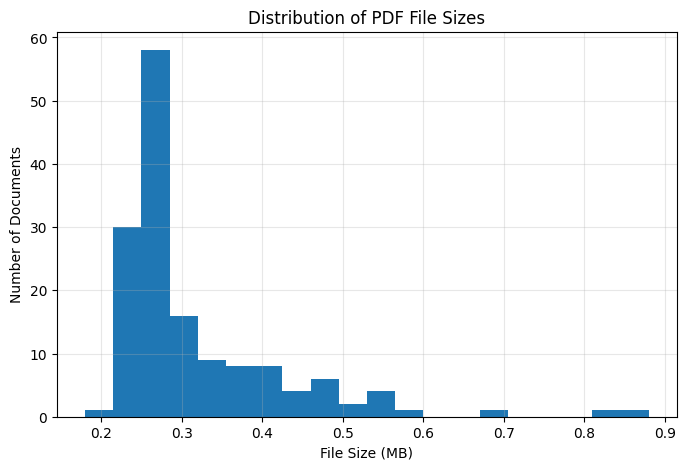

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    dataset_df["File_Size_MB"],
    bins=20
)

plt.title("Distribution of PDF File Sizes")

plt.xlabel("File Size (MB)")

plt.ylabel("Number of Documents")

plt.grid(alpha=0.3)

plt.show()

### SECTION 1 | CELL 8
**SAVE DATASET REPORT**

In [7]:
output_file = PROJECT_DIRS["results"] / "dataset_statistics.csv"

dataset_df.to_csv(
    output_file,
    index=False
)

print(f"Saved : {output_file}")

Saved : e:\Legal Finale\results\dataset_statistics.csv


### SECTION 2 | CELL 9
**IMPORT PDF PROCESSING LIBRARIES**

In [8]:
import fitz
import pytesseract

from pdf2image import convert_from_path

print("PDF Processing Libraries Loaded")

PDF Processing Libraries Loaded


### SECTION 2 | CELL 10
**EXTRACTION HELPER FUNCTIONS**

In [9]:
OCR_THRESHOLD = CONFIG["OCR_THRESHOLD"]


def extract_text_pymupdf(pdf_path):
    """
    Extract text using PyMuPDF.
    """

    document = fitz.open(pdf_path)

    text = ""

    for page in document:
        text += page.get_text()

    pages = len(document)

    document.close()

    return text, pages


def extract_text_ocr(pdf_path):
    """
    OCR extraction using Tesseract.
    """

    images = convert_from_path(pdf_path)

    text = ""

    for image in images:

        text += pytesseract.image_to_string(image)

        text += "\n"

    return text


print("Extraction Functions Ready")

Extraction Functions Ready


### SECTION 2 | CELL 11
**PDF EXTRACTION**

In [10]:
extraction_results = []

print("="*80)
print("PDF EXTRACTION STARTED")
print("="*80)

for pdf in tqdm(pdf_files):

    start = time.time()

    extraction_method = "PyMuPDF"

    text = ""

    pages = 0

    # --------------------------------------------------------
    # NORMAL EXTRACTION
    # --------------------------------------------------------

    try:

        text, pages = extract_text_pymupdf(pdf)

    except Exception:

        text = ""

    # --------------------------------------------------------
    # OCR IF REQUIRED
    # --------------------------------------------------------

    if len(text.strip()) < OCR_THRESHOLD:

        extraction_method = "OCR"

        try:

            text = extract_text_ocr(pdf)

        except Exception:

            text = ""

    # --------------------------------------------------------
    # SAVE TEXT
    # --------------------------------------------------------

    output_file = PROJECT_DIRS["extracted"] / f"{pdf.stem}.txt"

    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(text)

    end = time.time()

    words = len(text.split())

    extraction_results.append({

        "Document": pdf.name,

        "Pages": pages,

        "Characters": len(text),

        "Words": words,

        "Characters_Per_Page":
            round(
                len(text)/max(pages,1),
                2
            ),

        "Method": extraction_method,

        "Time_sec":
            round(
                end-start,
                2
            )
    })

print("\nExtraction Completed")

PDF EXTRACTION STARTED


100%|██████████| 150/150 [00:08<00:00, 18.07it/s]


Extraction Completed


### SECTION 2 | CELL 12
**EXTRACTION REPORT**

In [11]:
extraction_df = pd.DataFrame(extraction_results)

display(extraction_df.head())

print("="*80)

print("EXTRACTION SUMMARY")

print("="*80)

print(f"Documents Processed : {len(extraction_df)}")

print(f"Average Pages : {extraction_df['Pages'].mean():.2f}")

print(f"Average Words : {extraction_df['Words'].mean():.2f}")

print(f"Average Characters : {extraction_df['Characters'].mean():.2f}")

print(f"Average Time : {extraction_df['Time_sec'].mean():.2f} sec")

print()

print(extraction_df["Method"].value_counts())

,Document,Pages,Characters,Words,Characters_Per_Page,Method,Time_sec
0,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,36,70611,9933,1961.42,PyMuPDF,0.12
1,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,36,70575,9933,1960.42,PyMuPDF,0.04
2,Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...,9,28849,4651,3205.44,PyMuPDF,0.02
3,Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...,14,42509,6834,3036.36,PyMuPDF,0.03
4,Copy of Agartala_Municipal_Corporation_vs_Smt_...,43,133437,17744,3103.19,PyMuPDF,0.08


EXTRACTION SUMMARY
Documents Processed : 150
Average Pages : 38.33
Average Words : 15197.23
Average Characters : 99483.67
Average Time : 0.05 sec

Method
PyMuPDF    150
Name: count, dtype: int64


### SECTION 2 | CELL 13
**EXTRACTION VISUALIZATION**

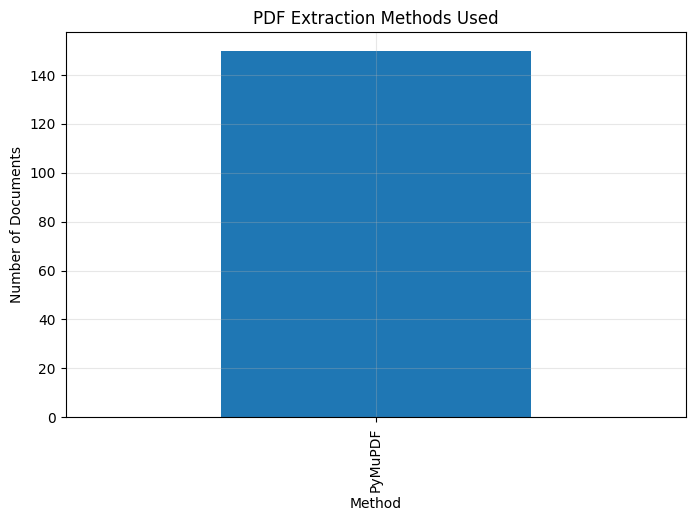

In [12]:
plt.figure(figsize=(8,5))

extraction_df["Method"].value_counts().plot(
    kind="bar"
)

plt.title("PDF Extraction Methods Used")

plt.xlabel("Method")

plt.ylabel("Number of Documents")

plt.grid(alpha=0.3)

plt.show()

### SECTION 2 | CELL 14
**SAVE REPORT**

In [13]:
output_file = PROJECT_DIRS["results"] / "pdf_extraction_report.csv"

extraction_df.to_csv(
    output_file,
    index=False
)

print(f"Saved : {output_file}")

Saved : e:\Legal Finale\results\pdf_extraction_report.csv


# SECTION 03 : Advanced Legal Document Preprocessing

## Objective

Legal judgments extracted from PDF files often contain OCR artifacts, repeated headers, page numbers, download information, inconsistent whitespace, and formatting issues that negatively affect downstream NLP tasks.

This section implements a research-oriented preprocessing pipeline specifically designed for Indian legal judgments. The preprocessing preserves legal structure while removing irrelevant noise.

## Proposed Cleaning Pipeline

### Pass 1 : Structural Cleaning
- Unicode Normalization
- Line Ending Normalization
- Header Detection
- Footer Detection
- Page Number Removal
- Paragraph Preservation

### Pass 2 : Semantic Cleaning
- OCR Error Correction
- URL & Email Removal
- Citation Normalization
- Legal Section Normalization
- Whitespace Normalization

## Outputs

- Cleaned Documents
- Cleaning Report
- Cleaning Statistics
- Cleaning Quality Scores
- Processing Logs

### SECTION 03 | CELL 2
**IMPORT LIBRARIES**

In [14]:
import re
import json
import time
import string
import logging
import unicodedata

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

### SECTION 03 | CELL 3
**CONFIGURATION**

In [15]:
VALIDATION_MODE = False
VALIDATION_SAMPLE = 150

FORCE_REBUILD = False

MAX_HEADER_LINES = 4
MAX_FOOTER_LINES = 3

READING_SPEED_WPM = 220

print("="*70)
print("SECTION 03 CONFIGURATION LOADED")
print("="*70)

SECTION 03 CONFIGURATION LOADED


### SECTION 03 | CELL 4
**LOGGER**

In [16]:
LOG_FILE = PROJECT_DIRS["logs"] / "preprocessing.log"

logging.basicConfig(
    filename=LOG_FILE,
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    filemode="w"
)

logging.info("="*70)
logging.info("SECTION 03 STARTED")
logging.info("="*70)

print("Logger Initialized")

Logger Initialized


### SECTION 03 | CELL 5
**REGEX LIBRARY**

In [17]:
URL_PATTERN = re.compile(
    r"https?://\S+|www\.\S+",
    re.IGNORECASE
)

EMAIL_PATTERN = re.compile(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

PAGE_NUMBER_PATTERN = re.compile(
    r"^\s*(Page\s*)?\d+\s*(of\s*\d+)?\s*$",
    re.IGNORECASE
)

DOWNLOAD_PATTERN = re.compile(
    r".*Downloaded.*",
    re.IGNORECASE
)

INDIAN_KANOON_PATTERN = re.compile(
    r".*Indian Kanoon.*",
    re.IGNORECASE
)

MULTISPACE_PATTERN = re.compile(
    r"[ \t]{2,}"
)

MULTIBLANK_PATTERN = re.compile(
    r"\n{3,}"
)

AIR_PATTERN = re.compile(
    r"AIR\s*\n*\s*(\d{4})\s*\n*\s*([A-Za-z]+)\s*\n*\s*(\d+)",
    re.IGNORECASE
)

SCC_PATTERN = re.compile(
    r"\((\d{4})\)\s*\n*\s*(\d+)\s*SCC\s*\n*\s*(\d+)",
    re.IGNORECASE
)

print("Regex Library Loaded")

Regex Library Loaded


### SECTION 03 | CELL 6
**UNICODE NORMALIZATION**

In [18]:
def normalize_unicode(text):

    text = unicodedata.normalize("NFKC", text)

    replacements = {

        "“": '"',
        "”": '"',
        "‘": "'",
        "’": "'",
        "–": "-",
        "—": "-",
        "\u00A0": " ",
        "\ufb01": "fi",
        "\ufb02": "fl"

    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text

### SECTION 03 | CELL 7
**OCR CORRECTIONS**

In [19]:
OCR_CORRECTIONS = {

    "ﬁ":"fi",

    "ﬂ":"fl",

    "|":"I",

    "§":"Section"

}

def correct_ocr(text):

    for wrong,right in OCR_CORRECTIONS.items():

        text=text.replace(wrong,right)

    return text

### SECTION 03 | CELL 8
**LINE NORMALIZATION**

In [20]:
def normalize_lines(text):
    """
    Normalize document while preserving paragraph structure.
    """

    # Standardize line endings
    text = text.replace("\r\n", "\n")
    text = text.replace("\r", "\n")

    normalized_lines = []

    for line in text.split("\n"):

        # Remove leading/trailing spaces
        line = line.strip()

        # Collapse multiple spaces INSIDE the line only
        line = MULTISPACE_PATTERN.sub(" ", line)

        normalized_lines.append(line)

    return "\n".join(normalized_lines)

### SECTION 03 | CELL 9
**HEADER / FOOTER DETECTION**

In [21]:
def detect_repeated_lines(text, top_n=MAX_HEADER_LINES, bottom_n=MAX_FOOTER_LINES):
    """
    Detect repeated header/footer lines by analysing page-like blocks.
    Works well for judgments extracted page-wise.
    """

    pages = re.split(r"\f", text)

    if len(pages) < 2:
        return set(), set()

    header_counter = Counter()
    footer_counter = Counter()

    for page in pages:

        lines = [line.strip() for line in page.split("\n") if line.strip()]

        if len(lines) < 5:
            continue

        for line in lines[:top_n]:
            header_counter[line] += 1

        for line in lines[-bottom_n:]:
            footer_counter[line] += 1

    threshold = max(2, int(len(pages) * 0.6))

    headers = {
        line for line, count in header_counter.items()
        if count >= threshold
    }

    footers = {
        line for line, count in footer_counter.items()
        if count >= threshold
    }

    return headers, footers

### SECTION 03 | CELL 10
**PASS 1 : STRUCTURAL CLEANING**

In [22]:
def structural_cleaning(text):

    text = normalize_unicode(text)

    text = normalize_lines(text)

    headers, footers = detect_repeated_lines(text)

    cleaned_lines = []

    for line in text.split("\n"):

        stripped = line.strip()

        if not stripped:
            cleaned_lines.append("")
            continue

        if stripped in headers:
            continue

        if stripped in footers:
            continue

        if PAGE_NUMBER_PATTERN.fullmatch(stripped):
            continue

        cleaned_lines.append(line)

    text = "\n".join(cleaned_lines)

    # Preserve paragraphs
    text = MULTIBLANK_PATTERN.sub("\n\n", text)

    return text

### SECTION 03 | CELL 11
**CITATION NORMALIZATION**

In [23]:
def normalize_citations(text):

    def air_replace(match):
        return f"AIR {match.group(1)} {match.group(2).upper()} {match.group(3)}"

    def scc_replace(match):
        return f"({match.group(1)}) {match.group(2)} SCC {match.group(3)}"

    text = AIR_PATTERN.sub(air_replace, text)

    text = SCC_PATTERN.sub(scc_replace, text)

    return text

### SECTION 03 | CELL 12
**LEGAL SECTION NORMALIZATION**

In [24]:
SECTION_NORMALIZATION = {

    r"\bSec\.\b": "Section",

    r"\bSec\b": "Section",

    r"\bS\.\s*(\d+)": r"Section \1"

}

def normalize_sections(text):

    for pattern, replacement in SECTION_NORMALIZATION.items():

        text = re.sub(
            pattern,
            replacement,
            text,
            flags=re.IGNORECASE
        )

    return text

### SECTION 03 | CELL 13
**PASS 2 : SEMANTIC CLEANING**

In [25]:
def semantic_cleaning(text):

    text = correct_ocr(text)

    text = URL_PATTERN.sub("", text)

    text = EMAIL_PATTERN.sub("", text)

    text = DOWNLOAD_PATTERN.sub("", text)

    text = INDIAN_KANOON_PATTERN.sub("", text)

    text = normalize_citations(text)

    text = normalize_sections(text)

    cleaned_lines = []

    for line in text.split("\n"):

        line = MULTISPACE_PATTERN.sub(" ", line)

        cleaned_lines.append(line.rstrip())

    text = "\n".join(cleaned_lines)

    text = MULTIBLANK_PATTERN.sub("\n\n", text)

    return text.strip()

### SECTION 03 | CELL 14
**QUALITY SCORE**

In [26]:
def calculate_quality_score(text):

    score = 100

    invalid = sum(

        1

        for c in text

        if c not in string.printable and c not in "\n\t"

    )

    score -= invalid * 0.05

    excessive_blank = len(re.findall(r"\n{4,}", text))

    score -= excessive_blank * 0.5

    long_spaces = len(re.findall(r" {5,}", text))

    score -= long_spaces * 0.2

    return round(max(score, 0), 2)

### SECTION 03 | CELL 15
**MAIN CLEANING ENGINE**

In [27]:
def preprocess_document(text):

    original_characters = len(text)

    original_words = len(text.split())

    start = time.time()

    # PASS 1
    text = structural_cleaning(text)

    # PASS 2
    text = semantic_cleaning(text)

    end = time.time()

    quality = calculate_quality_score(text)

    result = {

        "clean_text": text,

        "original_characters": original_characters,

        "cleaned_characters": len(text),

        "characters_removed":
            original_characters - len(text),

        "original_words": original_words,

        "cleaned_words": len(text.split()),

        "paragraphs":
            len([

                p

                for p in text.split("\n\n")

                if p.strip()

            ]),

        "processing_time":
            round(end - start, 3),

        "quality_score":
            quality

    }

    return result

In [28]:
sample_file = sorted(PROJECT_DIRS["extracted"].glob("*.txt"))[0]

with open(sample_file, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

result = preprocess_document(raw_text)

print("=" * 80)
print("Paragraph Count :", result["paragraphs"])
print("Quality Score   :", result["quality_score"])
print("=" * 80)

print(result["clean_text"][:3000])

Paragraph Count : 36
Quality Score   : 99.5
2024:Mlhc:62 vs The State Of Meghalaya Through Its on 11 July,
Author: H. S. Thangkhiew
Bench: H. S. Thangkhiew
2024:MLHC:621
Serial No. 01-15
Supplementary List
HIGH COURT OF MEGHALAYA
AT SHILLONG
WP(C) No. 403 of 2021 with
WP(C) No. 285 of 2022
WP(C) No. 507 of 2022
WP(C) No. 508 of 2022
WP(C) No. 509 of 2022
WP(C) No. 510 of 2022
WP(C) No. 511 of 2022
WP(C) No. 512 of 2022
WP(C) No. 513 of 2022
WP(C) No. 514 of 2022
WP(C) No. 520 of 2022
WP(C) No. 521 of 2022
WP(C) No. 522 of 2022
WP(C) No. 523 of 2022
WP(C) No. 524 of 2022
Date of Decision: 11.07.2024
WP(C) No. 403 of 2021
1. Shri Eniwelstar Marwein,
S/o Allaudin Miah,
R/o Pdengshnong Golflinks,
Shillong, East Khasi Hills District,
Meghalaya.
2. Shri Krostarwell Thongni,
S/o Shri Baristar Kharsyntiew,
R/o Ladweitang, Nongstoin,
West Khasi Hills District,
Meghalaya.
3. Shri Emerald Kurbah,
S/o Shri Irol Lyngdoh Nonglait,
R/o Pyndengrei, Nongstoin,
West Khasi Hills District,
Meghalaya.
2024

### SECTION 03 | CELL 16
**PROCESS ALL DOCUMENTS**

In [29]:
processing_results = []

source_files = sorted(PROJECT_DIRS["extracted"].glob("*.txt"))

if VALIDATION_MODE:
    source_files = source_files[:VALIDATION_SAMPLE]

print("=" * 80)
print("PROCESSING LEGAL DOCUMENTS")
print("=" * 80)
print(f"Documents Found : {len(source_files)}")

for case_number, file in enumerate(tqdm(source_files), start=1):

    with open(
        file,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        raw_text = f.read()

    result = preprocess_document(raw_text)

    case_id = f"CASE{case_number:04d}"

    result["Case_ID"] = case_id
    result["Source_File"] = file.name

    processing_results.append(result)

print("\nProcessing Completed Successfully")

PROCESSING LEGAL DOCUMENTS
Documents Found : 150


  0%|          | 0/150 [00:00<?, ?it/s]


Processing Completed Successfully


### SECTION 03 | CELL 17
**SAVE CLEANED DOCUMENTS**

In [30]:
for item in tqdm(processing_results):

    output_file = PROJECT_DIRS["cleaned"] / item["Source_File"]

    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as f:

        # Save only the cleaned legal text
        f.write(item["clean_text"])

print("All cleaned documents saved successfully.")

  0%|          | 0/150 [00:00<?, ?it/s]

All cleaned documents saved successfully.


### SECTION 03 | CELL 18
**MANIFEST**

In [31]:
manifest = pd.DataFrame({

    "Case_ID":
        [x["Case_ID"] for x in processing_results],

    "Original_File":
        [x["Source_File"] for x in processing_results],

    "Cleaned_File":
        [x["Source_File"] for x in processing_results]

})

manifest.to_csv(
    PROJECT_DIRS["results"] / "manifest.csv",
    index=False
)

print(manifest.head())

    Case_ID                                      Original_File  \
0  CASE0001  Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...   
1  CASE0002  Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...   
2  CASE0003  Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...   
3  CASE0004  Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...   
4  CASE0005  Copy of Agartala_Municipal_Corporation_vs_Smt_...   

                                        Cleaned_File  
0  Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...  
1  Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...  
2  Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...  
3  Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...  
4  Copy of Agartala_Municipal_Corporation_vs_Smt_...  


### SECTION 03 | CELL 19
**CLEANING REPORT**

In [32]:
cleaning_df = pd.DataFrame({

    "Case_ID":

        [x["Case_ID"] for x in processing_results],

    "Characters_Before":

        [x["original_characters"] for x in processing_results],

    "Characters_After":

        [x["cleaned_characters"] for x in processing_results],

    "Characters_Removed":

        [x["characters_removed"] for x in processing_results],

    "Words_Before":

        [x["original_words"] for x in processing_results],

    "Words_After":

        [x["cleaned_words"] for x in processing_results],

    "Paragraphs":

        [x["paragraphs"] for x in processing_results],

    "Quality":

        [x["quality_score"] for x in processing_results],

    "Processing_Time":

        [x["processing_time"] for x in processing_results]

})

display(cleaning_df.head())

,Case_ID,Characters_Before,Characters_After,Characters_Removed,Words_Before,Words_After,Paragraphs,Quality,Processing_Time
0,CASE0001,70611,67584,3027,9933,9740,36,99.50,0.101
1,CASE0002,70575,67584,2991,9933,9740,36,99.50,0.084
2,CASE0003,28849,27716,1133,4651,4606,9,100.00,0.037
3,CASE0004,42509,39856,2653,6834,6764,14,100.00,0.047
4,CASE0005,133437,107559,25878,17744,17485,43,83.25,0.132


### SECTION 03 | CELL 20
**STATISTICS**

In [33]:
statistics = {

    "Documents":

        len(cleaning_df),

    "Average_Words":

        round(cleaning_df["Words_After"].mean(),2),

    "Average_Paragraphs":

        round(cleaning_df["Paragraphs"].mean(),2),

    "Average_Quality":

        round(cleaning_df["Quality"].mean(),2),

    "Average_Time":

        round(cleaning_df["Processing_Time"].mean(),3)

}

print("="*70)

for key,value in statistics.items():

    print(f"{key:25}: {value}")

Documents                : 150
Average_Words            : 14977.59
Average_Paragraphs       : 42.22
Average_Quality          : 97.5
Average_Time             : 0.102


In [34]:
print(PROJECT_DIRS)

{'raw_pdfs': WindowsPath('e:/Legal Finale/data/raw_pdfs'), 'extracted': WindowsPath('e:/Legal Finale/data/extracted_text'), 'cleaned': WindowsPath('e:/Legal Finale/data/cleaned_text'), 'metadata': WindowsPath('e:/Legal Finale/data/metadata'), 'chunks': WindowsPath('e:/Legal Finale/data/chunks'), 'embeddings': WindowsPath('e:/Legal Finale/data/embeddings'), 'faiss': WindowsPath('e:/Legal Finale/data/faiss'), 'bm25': WindowsPath('e:/Legal Finale/data/bm25'), 'retrieval': WindowsPath('e:/Legal Finale/data/retrieval'), 'neo4j': WindowsPath('e:/Legal Finale/data/neo4j'), 'summaries': WindowsPath('e:/Legal Finale/data/summaries'), 'evaluation': WindowsPath('e:/Legal Finale/data/evaluation'), 'cache': WindowsPath('e:/Legal Finale/data/cache'), 'results': WindowsPath('e:/Legal Finale/results'), 'figures': WindowsPath('e:/Legal Finale/figures'), 'logs': WindowsPath('e:/Legal Finale/logs')}


### SECTION 03 | CELL 21
**SAVE REPORTS**

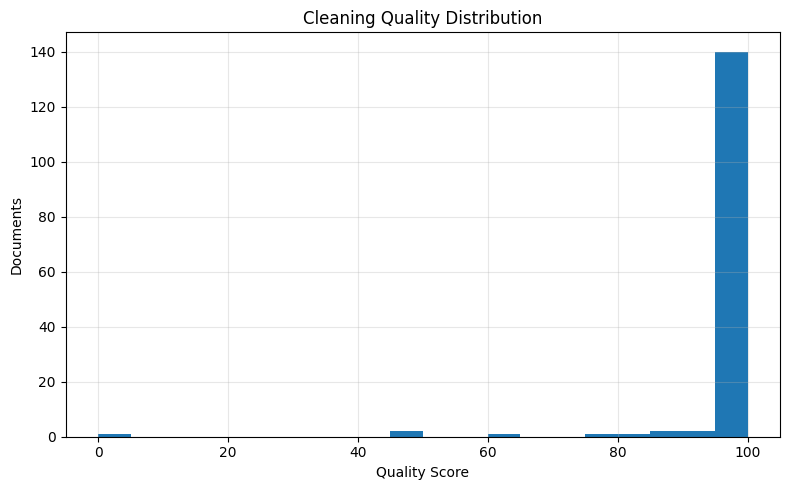

Reports Saved Successfully
CSV Report : e:\Legal Finale\results\cleaning_report.csv
JSON Stats : e:\Legal Finale\data\metadata\cleaning_statistics.json
Figure     : e:\Legal Finale\figures\figure_03_cleaning_quality.png


In [35]:
# CSV Report
cleaning_df.to_csv(
    PROJECT_DIRS["results"] / "cleaning_report.csv",
    index=False
)

# JSON Statistics
stats_file = PROJECT_DIRS["metadata"] / "cleaning_statistics.json"

with open(
    stats_file,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        statistics,
        f,
        indent=4
    )

# Figure
plt.figure(figsize=(8,5))

plt.hist(cleaning_df["Quality"], bins=20)

plt.xlabel("Quality Score")
plt.ylabel("Documents")
plt.title("Cleaning Quality Distribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_DIRS["figures"] /
    "figure_03_cleaning_quality.png",
    dpi=300
)

plt.show()

print("="*70)
print("Reports Saved Successfully")
print("="*70)

print("CSV Report :", PROJECT_DIRS["results"] / "cleaning_report.csv")
print("JSON Stats :", stats_file)
print("Figure     :", PROJECT_DIRS["figures"] / "figure_03_cleaning_quality.png")

### SECTION SUMMARY | CELL 22
****

In [36]:
print("="*80)

print("SECTION 03 COMPLETED")

print("="*80)

print(f"Documents Processed : {len(cleaning_df)}")

print(f"Average Quality     : {cleaning_df['Quality'].mean():.2f}")

print(f"Average Paragraphs  : {cleaning_df['Paragraphs'].mean():.2f}")

print(f"Manifest            : results/manifest.csv")

print(f"Cleaning Report     : results/cleaning_report.csv")

print(f"Statistics          : reports/cleaning_statistics.json")

print("\nSECTION 03 IS NOW LOCKED")

print("\nNext Section : Legal Metadata Intelligence Engine")

SECTION 03 COMPLETED
Documents Processed : 150
Average Quality     : 97.50
Average Paragraphs  : 42.22
Manifest            : results/manifest.csv
Cleaning Report     : results/cleaning_report.csv
Statistics          : reports/cleaning_statistics.json

SECTION 03 IS NOW LOCKED

Next Section : Legal Metadata Intelligence Engine


# SECTION 04 : Legal Metadata Intelligence Engine (LMIE)

## Objective

This section extracts high-quality document-level metadata from cleaned legal judgments.

Unlike traditional regex-based metadata extraction, this module combines:

- Region-aware extraction
- Legal heuristics
- Validation
- Confidence scoring
- Metadata normalization

The extracted metadata will later support:

- Case Classification
- Knowledge Graph Construction
- Citation Analysis
- Structure-aware Chunking
- GraphRAG Retrieval
- Summary Generation

## Metadata Extracted

- Case ID
- Case Title
- Court
- Neutral Citation
- Decision Date
- Petitioners
- Respondents
- Judges
- Bench Size
- Laws
- Legal Citations
- Statistics
- Confidence Scores
- Coverage Score

### SECTION 04 | CELL 1
**IMPORTS**

In [37]:
import re
import json
import logging
from collections import defaultdict

### SECTION 04 | CELL 2
**LOGGER**

In [38]:
METADATA_LOG = PROJECT_DIRS["logs"] / "metadata_engine.log"

logging.basicConfig(

    filename=METADATA_LOG,

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    filemode="w"

)

logging.info("="*70)
logging.info("LEGAL METADATA ENGINE STARTED")
logging.info("="*70)

print("Metadata Logger Ready")

Metadata Logger Ready


### SECTION 04 | CELL 9
**COURT EXTRACTOR (ENHANCED)**

In [39]:
import re

COURT_DATABASE = {
    "SUPREME COURT OF INDIA": "Supreme Court Of India",
    "THE SUPREME COURT OF INDIA": "Supreme Court Of India",
    "HIGH COURT OF ALLAHABAD": "Allahabad High Court",
    "ALLAHABAD HIGH COURT": "Allahabad High Court",
    "HIGH COURT OF BOMBAY": "Bombay High Court",
    "BOMBAY HIGH COURT": "Bombay High Court",
    "IN THE HIGH COURT OF JUDICATURE AT BOMBAY": "Bombay High Court",
    "HIGH COURT OF BOMBAY AT GOA": "Bombay High Court",
    "HIGH COURT OF CALCUTTA": "Calcutta High Court",
    "CALCUTTA HIGH COURT": "Calcutta High Court",
    "HIGH COURT AT CALCUTTA": "Calcutta High Court",
    "HIGH COURT OF CHHATTISGARH": "Chhattisgarh High Court",
    "CHHATTISGARH HIGH COURT": "Chhattisgarh High Court",
    "HIGH COURT OF DELHI": "Delhi High Court",
    "DELHI HIGH COURT": "Delhi High Court",
    "HIGH COURT OF GAUHATI": "Gauhati High Court",
    "GAUHATI HIGH COURT": "Gauhati High Court",
    "THE GAUHATI HIGH COURT": "Gauhati High Court",
    "HIGH COURT OF GUJARAT": "Gujarat High Court",
    "GUJARAT HIGH COURT": "Gujarat High Court",
    "HIGH COURT OF HIMACHAL PRADESH": "Himachal Pradesh High Court",
    "HIGH COURT OF JAMMU AND KASHMIR": "Jammu And Kashmir High Court",
    "HIGH COURT OF JAMMU AND KASHMIR AND LADAKH": "Jammu And Kashmir High Court",
    "HIGH COURT FOR THE STATE OF TELANGANA": "Telangana High Court",
    "TELANGANA HIGH COURT": "Telangana High Court",
    "HIGH COURT OF JHARKHAND": "Jharkhand High Court",
    "HIGH COURT OF KARNATAKA": "Karnataka High Court",
    "KARNATAKA HIGH COURT": "Karnataka High Court",
    "HIGH COURT OF KERALA": "Kerala High Court",
    "KERALA HIGH COURT": "Kerala High Court",
    "HIGH COURT OF MADHYA PRADESH": "Madhya Pradesh High Court",
    "MADHYA PRADESH HIGH COURT": "Madhya Pradesh High Court",
    "HIGH COURT OF MADRAS": "Madras High Court",
    "MADRAS HIGH COURT": "Madras High Court",
    "HIGH COURT OF MANIPUR": "Manipur High Court",
    "HIGH COURT OF MEGHALAYA": "Meghalaya High Court",
    "MEGHALAYA HIGH COURT": "Meghalaya High Court",
    "HIGH COURT OF ORISSA": "Orissa High Court",
    "ORISSA HIGH COURT": "Orissa High Court",
    "HIGH COURT OF ANDHRA PRADESH": "Andhra Pradesh High Court",
    "HIGH COURT OF PATNA": "Patna High Court",
    "HIGH COURT OF PUNJAB AND HARYANA": "Punjab And Haryana High Court",
    "HIGH COURT OF RAJASTHAN": "Rajasthan High Court",
    "RAJASTHAN HIGH COURT": "Rajasthan High Court",
    "HIGH COURT OF SIKKIM": "Sikkim High Court",
    "HIGH COURT OF TRIPURA": "Tripura High Court",
    "HIGH COURT OF UTTARAKHAND": "Uttarakhand High Court",
    "HIGH COURT OF UTTARANCHAL": "Uttarakhand High Court",
    "NATIONAL CONSUMER DISPUTES REDRESSAL COMMISSION": "National Consumer Disputes Redressal Commission",
    "NATIONAL COMPANY LAW TRIBUNAL": "National Company Law Tribunal",
    "NATIONAL COMPANY LAW APPELLATE TRIBUNAL": "National Company Law Appellate Tribunal",
    "DEBT RECOVERY TRIBUNAL": "Debt Recovery Tribunal",
    "DEBT RECOVERY APPELLATE TRIBUNAL": "Debt Recovery Appellate Tribunal"
}

def extract_court(lines):
    SEARCH_LIMIT = min(60, len(lines))

    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx]).upper()
        if not line: continue
        
        for alias, canonical in COURT_DATABASE.items():
            if alias in line:
                return {
                    "Court": canonical,
                    "Court_Confidence": 1.00,
                    "Court_Source_Line": idx + 1,
                    "Court_Method": "Court Database"
                }

    # Fallback: aggressive regex for IN THE HIGH COURT OF...
    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx]).upper()
        m_regex = re.search(r"IN THE (?:HIGH|SUPREME) COURT (?:OF|AT) ([A-Z\s]+)", line)
        if m_regex:
            return {
                "Court": ("High Court Of " + m_regex.group(1).title().strip()),
                "Court_Confidence": 0.80,
                "Court_Source_Line": idx + 1,
                "Court_Method": "Aggressive Regex Fallback"
            }

    # Fallback: generic HIGH COURT / SUPREME COURT detection
    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx]).upper()
        if "SUPREME COURT" in line:
            return {
                "Court": "Supreme Court Of India",
                "Court_Confidence": 0.70,
                "Court_Source_Line": idx + 1,
                "Court_Method": "Fallback Pattern"
            }
        if "HIGH COURT" in line:
            m = re.search(r"HIGH COURT(?:\s+OF(?:\s+THE)?)?\s+([A-Z\s]+)", line)
            court_name = ("High Court Of " + m.group(1).title().strip()) if m else "High Court (Unknown)"
            return {
                "Court": court_name,
                "Court_Confidence": 0.60,
                "Court_Source_Line": idx + 1,
                "Court_Method": "Fallback Pattern"
            }

    return {
        "Court": None,
        "Court_Confidence": 0.0,
        "Court_Source_Line": None,
        "Court_Method": None
    }

print(f"{len(COURT_DATABASE)} Court Aliases Loaded")

53 Court Aliases Loaded


### SECTION 04 | CELL 4
**METADATA PATTERNS**

In [40]:
PATTERNS = {

"neutral_citation":

re.compile(

r"\b\d{4}:[A-Z]{2,10}:\d+\b",

re.IGNORECASE

),

"decision_date":

re.compile(

r"Date\s+of\s+Decision\s*[:\-]?\s*(\d{2}[./-]\d{2}[./-]\d{4})",

re.IGNORECASE

),

"judge":

re.compile(

r"(?:HON'?BLE\s+)?(?:MR\.?|MS\.?|MRS\.?)?\s*JUSTICE\s+([A-Z][A-Za-z.\s]+?)(?=,|\n|J\.|JJ\.|$)",

re.IGNORECASE

),

"article":

re.compile(

r"\bArticle\s+\d+[A-Za-z()/-]*",

re.IGNORECASE

),

"section":

re.compile(

r"\bSection\s+\d+[A-Za-z()/-]*",

re.IGNORECASE

),

"rule":

re.compile(

r"\bRule\s+\d+[A-Za-z()/-]*",

re.IGNORECASE

),

"scc":

re.compile(

r"\(\d{4}\)\s*\d+\s*SCC\s*\d+",

re.IGNORECASE

),

"air":

re.compile(

r"AIR\s+\d{4}\s+[A-Z]+\s+\d+",

re.IGNORECASE

)

}

print("Metadata Patterns Ready")

Metadata Patterns Ready


### SECTION 04 | CELL 5
**HELPERS**

In [41]:
def unique(items):

    return list(dict.fromkeys(items))


def clean_text(text):

    return re.sub(

        r"\s+",

        " ",

        str(text)

    ).strip()


def confidence(found):

    return 1.0 if found else 0.0


print("Helper Functions Ready")

Helper Functions Ready


### SECTION 04 | CELL 6
**METADATA OBJECT**

In [42]:
def create_metadata_object(case_id):

    return {

        "Case_ID": case_id,

        "Metadata": {

            "Case_Title":None,

            "Court":None,

            "Neutral_Citation":None,

            "Decision_Date":None,

            "Petitioners":[],

            "Respondents":[],

            "Judges":[],

            "Bench_Size":0,

            "Laws":[],

            "Citations":[]

        },

        "Statistics":{

            "Words":0,

            "Paragraphs":0,

            "Characters":0

        },

        "Confidence":{

            "Court":0,

            "Judge":0,

            "Parties":0,

            "Decision_Date":0,

            "Citation":0,

            "Laws":0

        },

        "Coverage":0

    }

print("Metadata Object Ready")

Metadata Object Ready


### SECTION 04 | CELL 7
**DOCUMENT LOADER**

In [43]:
cleaned_documents = sorted(

    PROJECT_DIRS["cleaned"].glob("*.txt")

)

print("="*70)

print(f"Cleaned Documents Found : {len(cleaned_documents)}")

print("="*70)

Cleaned Documents Found : 150


### SECTION 04 | CELL 8
**DOCUMENT UTILITIES**

In [44]:
def document_lines(text):
    """
    Split document into cleaned lines.
    Empty lines are preserved for positional consistency.
    """

    return [line.rstrip() for line in text.split("\n")]


def search_region(lines, start=0, end=None):

    if end is None:
        end = len(lines)

    return lines[start:end]


def normalize_value(value):

    if value is None:
        return None

    value = re.sub(r"\s+", " ", str(value))

    return value.strip()

### SECTION 04 | CELL 9 (DUPLICATE REMOVED)
****

In [45]:
print("Court extractor previously initialized with enhanced features in Cell 41.")

Court extractor previously initialized with enhanced features in Cell 41.


### SECTION 04 | CELL 10
**CASE TITLE EXTRACTOR (ENHANCED MULTI-LINE)**

In [46]:
from pathlib import Path

def extract_case_title(lines, source_file=None):
    SEARCH_LIMIT = min(50, len(lines))
    
    # Check for split lines (e.g. "Petitioner \n vs \n Respondent")
    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx])
        
        if re.search(r"\b(vs\.?|versus|v\.)\b", line, re.IGNORECASE):
            # Try to build a title combining previous, current, and next line
            parts = []
            if idx > 0 and len(normalize_value(lines[idx-1])) > 3:
                parts.append(normalize_value(lines[idx-1]))
            parts.append(line)
            if idx < len(lines)-1 and len(normalize_value(lines[idx+1])) > 3:
                parts.append(normalize_value(lines[idx+1]))
                
            combined = " ".join(parts)
            # Clean up excessive titles
            combined = re.sub(r"\s+", " ", combined)
            if len(combined) > 10:
                return {
                    "Case_Title": combined,
                    "Case_Title_Confidence": 0.98,
                    "Case_Title_Source_Line": idx + 1,
                    "Case_Title_Method": "Multi-line Top Region"
                }

    # Fallback: derive title from filename robustly
    if source_file:
        stem = Path(source_file).stem
        stem = re.sub(r"^Copy of ", "", stem, flags=re.IGNORECASE)
        stem = re.sub(r"_on_[\d_A-Za-z]+$", "", stem)
        title = stem.replace("_", " ")
        if re.search(r"\b(vs|versus)\b", title, re.IGNORECASE):
            return {
                "Case_Title": title,
                "Case_Title_Confidence": 0.75,
                "Case_Title_Source_Line": None,
                "Case_Title_Method": "Filename Fallback"
            }

    return {
        "Case_Title": None,
        "Case_Title_Confidence": 0,
        "Case_Title_Source_Line": None,
        "Case_Title_Method": None
    }

### SECTION 04 | CELL 11
**DECISION DATE EXTRACTOR (V2 MERGED)**

In [47]:
DATE_PATTERNS = [
    re.compile(r"Date\s+of\s+Decision\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Decision\s+Date\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Pronounced\s+on\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Delivered\s+on\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Reserved\s+on\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Order\s+Dated\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Dated\s*[:\-]?\s*([^\n]+)", re.IGNORECASE),
    re.compile(r"Date\s*[:\-]?\s*([0-9./-]+)", re.IGNORECASE)
]

def extract_decision_date(lines):

    SEARCH_LIMIT = min(200, len(lines))

    for pattern in DATE_PATTERNS:

        for idx in range(SEARCH_LIMIT):

            match = pattern.search(lines[idx])

            if match:

                return {
                    "Decision_Date": normalize_value(match.group(1)),
                    "Decision_Date_Confidence": 1.0,
                    "Decision_Date_Source_Line": idx + 1,
                    "Decision_Date_Method": "Priority Pattern"
                }

    return {
        "Decision_Date": None,
        "Decision_Date_Confidence": 0.0,
        "Decision_Date_Source_Line": None,
        "Decision_Date_Method": None
    }

print("Decision Date Extractor Ready")

Decision Date Extractor Ready


### SECTION 04 | CELL 12
**TEST MODULES**

In [48]:
manifest = pd.read_csv(
    PROJECT_DIRS["results"] / "manifest.csv"
)

sample_file = PROJECT_DIRS["cleaned"] / manifest.iloc[0]["Cleaned_File"]

with open(
    sample_file,
    "r",
    encoding="utf-8",
    errors="ignore"
) as f:

    sample_text = f.read()

lines = document_lines(sample_text)

court = extract_court(lines)

title = extract_case_title(lines)

decision = extract_decision_date(lines)

print("="*80)

print("COURT")
print(court)

print("\nCASE TITLE")
print(title)

print("\nDECISION DATE")
print(decision)

COURT
{'Court': 'Meghalaya High Court', 'Court_Confidence': 1.0, 'Court_Source_Line': 7, 'Court_Method': 'Court Database'}

CASE TITLE
{'Case_Title': '2024:Mlhc:62 vs The State Of Meghalaya Through Its on 11 July, Author: H. S. Thangkhiew', 'Case_Title_Confidence': 0.98, 'Case_Title_Source_Line': 1, 'Case_Title_Method': 'Multi-line Top Region'}

DECISION DATE
{'Decision_Date': '11.07.2024', 'Decision_Date_Confidence': 1.0, 'Decision_Date_Source_Line': 24, 'Decision_Date_Method': 'Priority Pattern'}


### SECTION 04 | CELL 13
**NEUTRAL CITATION EXTRACTOR (V2 MERGED)**

In [49]:
NEUTRAL_PATTERNS = [
    # 2024:MLHC:621
    re.compile(r"\b(\d{4}:[A-Z]{2,10}:\d+(?:-[A-Z]+)?)\b", re.IGNORECASE),
    # 2024 INSC 113
    re.compile(r"\b(\d{4}\s+INSC\s+\d+)\b", re.IGNORECASE),
    # 2026:CGHC:18917
    re.compile(r"\b(\d{4}:[A-Z]{2,10}:\d+)\b", re.IGNORECASE),
    # 2025 KHC 104683
    re.compile(r"\b(\d{4}\s+KHC\s+\d+)\b", re.IGNORECASE),
    # 2025 DLHC 8765
    re.compile(r"\b(\d{4}\s+DLHC\s+\d+)\b", re.IGNORECASE)
]

def extract_neutral_citation(lines):
    
    header = "\n".join(lines[:250])
    candidates = []

    for pattern in NEUTRAL_PATTERNS:
        for match in pattern.finditer(header):
            value = normalize_value(match.group(1))
            score = 0
            
            # Prefer citations appearing early
            score += max(0, 250 - match.start())
            
            # Prefer High Court / Supreme Court abbreviations
            if any(code in value.upper() for code in ["INSC", "MLHC", "DLHC", "CGHC", "KHC", "SC"]):
                score += 500
                
            candidates.append((score, value))

    if candidates:
        candidates.sort(reverse=True)
        best = candidates[0][1]
        source_line = None

        for idx, line in enumerate(lines[:250], start=1):
            if best in line:
                source_line = idx
                break

        return {
            "Neutral_Citation": best,
            "Neutral_Citation_Confidence": 1.0,
            "Neutral_Citation_Source_Line": source_line,
            "Neutral_Citation_Method": "Priority Candidate Ranking"
        }

    return {
        "Neutral_Citation": None,
        "Neutral_Citation_Confidence": 0.0,
        "Neutral_Citation_Source_Line": None,
        "Neutral_Citation_Method": None
    }

print("Neutral Citation Extractor Ready")

Neutral Citation Extractor Ready


### SECTION 04 | CELL 14
**CASE NUMBER EXTRACTOR (EXPANDED)**

In [50]:
CASE_NUMBER_PATTERN = re.compile(
    r"\b(?:"
    r"W\.?P\.?\s*\(?[A-Z]*\)?"
    r"|CRL?\.?\s*\(?[A-Z]*\)?"
    r"|C\.?A\.?|CIVIL\s+APPEAL"
    r"|CRIMINAL\s+APPEAL"
    r"|S\.?L\.?P\.?(?:\s*\([A-Z]+\))?"
    r"|L\.?P\.?A\.?"
    r"|R\.?S\.?A\.?"
    r"|F\.?A\.?O\.?(?:\s*\([A-Z]+\))?"
    r"|MAC\s+APP(?:EAL)?"
    r"|R\.?F\.?A\.?"
    r"|M\.?F\.?A\.?"
    r"|O\.?S\.?A\.?"
    r"|C\.?S\.?\s*\(?O\.?S\.?\)?"
    r"|C\.?O\.?"
    r"|C\.?M\.?\s*\(?[A-Z]*\)?"
    r"|O\.?A\.?"
    r"|T\.?A\.?"
    r"|M\.?A\.?"
    r"|I\.?A\.?"
    r"|A\.?S\.?"
    r"|E\.?P\.?"
    r"|BAIL\s+APPL"
    r"|CONTEMPT\s+(?:PETITION|CASE)"
    r"|EXECUTION\s+PETITION"
    r"|SUIT"
    r"|RVPET|REVISION\s+PETITION"
    r"|WRIT\s+PETITION"
    r"|LETTERS\s+PATENT\s+APPEAL"
    r"|FIRST\s+APPEAL"
    r"|SECOND\s+APPEAL"
    r"|TRANSFER\s+PETITION"
    r"|ORIGINAL\s+PETITION"
    r"|MISC(?:ELLANEOUS)?\s+(?:PETITION|APPLICATION|APPEAL|CASE)"
    r"|ARB\.?\s*A\.?"
    r")"
    r"(?:\s*\([A-Z]+\))?"
    r"\s*[.\-]?\s*"
    r"(?:No\.?\s*)?"
    r"[\d/]+"
    r"(?:[/\-]\d+)*"
    r"(?:\s+of\s+\d{4})?",
    re.IGNORECASE
)

def extract_case_number(lines):
    SEARCH_LIMIT = min(200, len(lines))

    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx])
        match = CASE_NUMBER_PATTERN.search(line)
        if match:
            return {
                "Case_Number": match.group().strip(),
                "Case_Number_Confidence": 0.95,
                "Case_Number_Source_Line": idx + 1,
                "Case_Number_Method": "Expanded Regex"
            }

    # Generic fallback
    for idx in range(SEARCH_LIMIT):
        line = normalize_value(lines[idx])
        
        # Broader generic fallback: e.g. "Case No. 123/2024", "Crl.A. No. 45-47 of 2024"
        m = re.search(
            r"[A-Z][A-Za-z.\s()/]+No\.?\s*[\d/]+(?:[\-][\d/]+)*(?:\s+of\s+\d{4})?",
            line,
            re.IGNORECASE
        )
        if m:
            return {
                "Case_Number": m.group().strip(),
                "Case_Number_Confidence": 0.70,
                "Case_Number_Source_Line": idx + 1,
                "Case_Number_Method": "Generic Fallback"
            }

    return {
        "Case_Number": None,
        "Case_Number_Confidence": 0,
        "Case_Number_Source_Line": None,
        "Case_Number_Method": None
    }

print("Case Number Extractor Ready")

Case Number Extractor Ready


### SECTION 04 | CELL 15
**JUDGE EXTRACTOR**

In [51]:
AUTHOR_PATTERN = re.compile(
    r"Author\s*:\s*(.+)",
    re.IGNORECASE
)

BENCH_PATTERN = re.compile(
    r"Bench\s*:\s*(.+)",
    re.IGNORECASE
)

JUSTICE_PATTERN = re.compile(
    r"(?:HON'?BLE\s+)?(?:MR\.?|MS\.?|MRS\.?)?\s*(?:JUSTICE|JUDGE|CHIEF JUSTICE)\s+([A-Za-z.\s]+)",
    re.IGNORECASE
)

CORAM_PATTERN = re.compile(
    r"^(?:CORAM|BEFORE|PRESENT)\s*:\s*(.+)",
    re.IGNORECASE
)

def clean_judge_name(name):
    name = normalize_value(name)
    name = re.sub(r"\b(?:J\.?|CJ\.?|JJ\.?)$", "", name, flags=re.IGNORECASE).strip()
    return name

def split_judges(text):
    # Splits by commas and "and" / "&"
    parts = re.split(r",|\band\b|&", text, flags=re.IGNORECASE)
    judges = []
    for p in parts:
        cl = clean_judge_name(p)
        if len(cl) > 3 and not re.match(r"^(hon'?ble|mr|ms|mrs|justice|judge)", cl, re.IGNORECASE):
            judges.append(cl)
        else:
            # If it still contains justice/judge, extract the name part
            m = JUSTICE_PATTERN.search(p)
            if m:
                judges.append(clean_judge_name(m.group(1)))
            elif len(cl) > 3:
                judges.append(cl)
    return judges

def extract_judges(lines):
    SEARCH_LIMIT = min(150, len(lines))
    judges = []
    methods = []
    source_lines = []

    # ---------- Strategy 1 : Author ----------
    for idx in range(SEARCH_LIMIT):
        match = AUTHOR_PATTERN.search(lines[idx])
        if match:
            for j in split_judges(match.group(1)):
                judges.append(j)
                methods.append("Author")
                source_lines.append(idx + 1)

    # ---------- Strategy 2 : Bench / Coram / Before ----------
    for idx in range(SEARCH_LIMIT):
        match_bench = BENCH_PATTERN.search(lines[idx])
        if match_bench:
            for j in split_judges(match_bench.group(1)):
                judges.append(j)
                methods.append("Bench")
                source_lines.append(idx + 1)
                
        match_coram = CORAM_PATTERN.search(lines[idx])
        if match_coram:
            text = match_coram.group(1)
            if len(text.strip()) > 3:
                for j in split_judges(text):
                    judges.append(j)
                    methods.append("Coram/Before")
                    source_lines.append(idx + 1)
            else:
                # the names might be on the next few lines
                for next_idx in range(idx + 1, min(idx + 10, len(lines))):
                    nl = lines[next_idx].strip()
                    if not nl: continue
                    m = JUSTICE_PATTERN.search(nl)
                    if m:
                        judges.append(clean_judge_name(m.group(1)))
                        methods.append("Coram/Before Multiline")
                        source_lines.append(next_idx + 1)
                    else:
                        break

    # ---------- Strategy 3 : Justice ----------
    for idx in range(SEARCH_LIMIT):
        for match in JUSTICE_PATTERN.finditer(lines[idx]):
            judges.append(clean_judge_name(match.group(1)))
            methods.append("Justice Pattern")
            source_lines.append(idx + 1)

    # Deduplicate judges (preserve order)
    seen = set()
    final_judges = []
    final_methods = []
    final_sources = []
    
    for j, m, s in zip(judges, methods, source_lines):
        key = re.sub(r"\s+", "", j).lower()
        if key not in seen and len(key) > 3:
            seen.add(key)
            final_judges.append(j)
            final_methods.append(m)
            final_sources.append(s)

    return {
        "Judges": final_judges if final_judges else None,
        "Judges_Confidence": 1.0 if final_judges else 0.0,
        "Judges_Source_Line": final_sources if final_sources else None,
        "Judges_Method": final_methods if final_methods else None
    }

print("Judge Extractor Ready")

Judge Extractor Ready


### SECTION 04 | CELL 16
**VALIDATE MODULES**

In [52]:
neutral = extract_neutral_citation(lines)

case_number = extract_case_number(lines)

judges = extract_judges(lines)

print("="*80)

print("NEUTRAL CITATION")
print(neutral)

print("\nCASE NUMBER")
print(case_number)

print("\nJUDGES")
print(judges)

NEUTRAL CITATION
{'Neutral_Citation': '2024:Mlhc:62', 'Neutral_Citation_Confidence': 1.0, 'Neutral_Citation_Source_Line': 1, 'Neutral_Citation_Method': 'Priority Candidate Ranking'}

CASE NUMBER
{'Case_Number': 'WP(C) No. 403 of 2021', 'Case_Number_Confidence': 0.95, 'Case_Number_Source_Line': 9, 'Case_Number_Method': 'Expanded Regex'}

JUDGES
{'Judges': ['H. S. Thangkhiew'], 'Judges_Confidence': 1.0, 'Judges_Source_Line': [2], 'Judges_Method': ['Author']}


### SECTION 04 | CELL 17
**BATCH CASE DETECTOR**

In [53]:
def detect_batch_case(lines):

    text = "\n".join(lines[:150])

    indicators = [

        len(re.findall(r"WP\(C\)", text, re.IGNORECASE)) > 1,

        len(re.findall(r"\bVersus\b", text, re.IGNORECASE)) > 1,

        len(re.findall(r"\bwith\b", text, re.IGNORECASE)) > 0,

        len(re.findall(r"connected", text, re.IGNORECASE)) > 0

    ]

    return any(indicators)

print("Batch Case Detector Ready")

Batch Case Detector Ready


### SECTION 04 | CELL 18
**PARTY NAME CLEANER**

In [54]:
TITLE_PATTERN = re.compile(
    r"^(Shri|Smt\.?|Smti|Mrs\.?|Mr\.?|Ms\.?|Dr\.?)\s+",
    re.IGNORECASE
)

def normalize_party_name(name):

    name = re.sub(
        r"\s+through\s+.*$",
        "",
        name,
        flags=re.IGNORECASE
    )

    # Remove trailing commas
    name = name.rstrip(",")
    
    name = normalize_value(name)

    name = TITLE_PATTERN.sub("", name)

    name = re.sub(r",$","",name)

    return name.strip()

### SECTION 04 | CELL 19
**PRINCIPAL PARTY EXTRACTOR (PROXIMITY-BASED)**

In [55]:
def extract_primary_parties(lines):

    batch_case = detect_batch_case(lines)

    petitioner = None
    respondent = None
    petitioner_line = None
    respondent_line = None
    
    SEARCH_LIMIT = min(300, len(lines))

    # Find the strictly standalone "Versus" separator
    versus_idx = None
    for idx in range(SEARCH_LIMIT):
        # Match lines that only contain "versus" or "vs" (with optional dashes)
        if re.search(r"^\s*[-_]*\s*(versus|vs\.?|v\.?)\s*[-_]*\s*$", lines[idx], re.IGNORECASE):
            versus_idx = idx
            break
            
    if versus_idx is not None:
        # Search backwards for Petitioner
        for idx in range(versus_idx - 1, -1, -1):
            clean = lines[idx].strip()
            # Must have some alphabetical characters and not be purely a date/number
            if len(clean) > 3 and re.search(r"[A-Za-z]{3,}", clean):
                name = re.sub(r"^\s*\d+[\.\)\-]\s*", "", clean)
                # Strip out "Petitioner(s)" labels
                name = re.sub(r"\.*\s*Petitioner\(s\).*$", "", name, flags=re.IGNORECASE)
                if len(name) > 3:
                    petitioner = normalize_party_name(name)
                    if petitioner:
                        petitioner_line = idx + 1
                        break

        # Search forwards for Respondent
        for idx in range(versus_idx + 1, min(len(lines), versus_idx + 80)):
            clean = lines[idx].strip()
            if len(clean) > 3 and re.search(r"[A-Za-z]{3,}", clean):
                name = re.sub(r"^\s*\d+[\.\)\-]\s*", "", clean)
                # Strip out "Respondent(s)" labels
                name = re.sub(r"\.*\s*Respondent\(s\).*$", "", name, flags=re.IGNORECASE)
                if not re.match(r"^(represented|through|c/o)\b", name, re.IGNORECASE):
                    respondent = normalize_party_name(name)
                    respondent = re.sub(r"\s+through.*", "", respondent, flags=re.IGNORECASE)
                    if respondent:
                        respondent_line = idx + 1
                        break

    # Fallback 1: Petitioner: [Name] ... Respondent: [Name]
    if not petitioner:
        for idx in range(SEARCH_LIMIT):
            line = lines[idx]
            m_pet = re.search(r"^(?:Petitioner|Appellant|Applicant)s?\s*[:\-]\s*([A-Za-z\s\.\(\)&]+)", line, re.IGNORECASE)
            if m_pet and len(m_pet.group(1).strip()) > 3:
                petitioner = normalize_party_name(m_pet.group(1))
                petitioner_line = idx + 1
                break
    
    if not respondent:
        for idx in range(SEARCH_LIMIT):
            line = lines[idx]
            m_res = re.search(r"^(?:Respondent|Defendant)s?\s*[:\-]\s*([A-Za-z\s\.\(\)&]+)", line, re.IGNORECASE)
            if m_res and len(m_res.group(1).strip()) > 3:
                respondent = normalize_party_name(m_res.group(1))
                respondent_line = idx + 1
                break

    # Fallback 2: "A vs B" on the same line
    if not petitioner or not respondent:
        for idx in range(min(50, len(lines))):
            m_vs = re.search(r"^\s*([A-Za-z\s\.\(\)&]+)\s+(?:versus|vs\.?|v\.?)\s+([A-Za-z\s\.\(\)&]+)\s*$", lines[idx], re.IGNORECASE)
            if m_vs:
                if not petitioner:
                    pet = normalize_party_name(m_vs.group(1))
                    if len(pet) > 3:
                        petitioner = pet
                        petitioner_line = idx + 1
                if not respondent:
                    res = normalize_party_name(m_vs.group(2))
                    if len(res) > 3:
                        respondent = res
                        respondent_line = idx + 1
                break

    return {
        "Primary_Petitioner": petitioner,
        "Primary_Respondent": respondent,
        "Batch_Case": batch_case,
        "Party_Confidence": 1.0 if petitioner or respondent else 0.0,
        "Petitioner_Source_Line": petitioner_line,
        "Respondent_Source_Line": respondent_line,
        "Party_Method": "Proximity Parser V5"
    }

def extract_advocates(lines):
    pet_advocate = None
    res_advocate = None
    SEARCH_LIMIT = min(300, len(lines))
    for idx in range(SEARCH_LIMIT):
        line = lines[idx]
        if not pet_advocate:
            m = re.search(r"For\s+(?:the\s+)?(?:Petitioner|Appellant)s?\s*[:\-]?\s*(?:Mr\.|Ms\.|Mrs\.|Dr\.)?\s*([A-Za-z\s\.,]+)", line, re.IGNORECASE)
            if m and len(m.group(1).strip()) > 3:
                pet_advocate = normalize_party_name(m.group(1))
        if not res_advocate:
            m = re.search(r"For\s+(?:the\s+)?(?:Respondent|Defendant)s?\s*[:\-]?\s*(?:Mr\.|Ms\.|Mrs\.|Dr\.)?\s*([A-Za-z\s\.,]+)", line, re.IGNORECASE)
            if m and len(m.group(1).strip()) > 3:
                res_advocate = normalize_party_name(m.group(1))
    return {
        "Petitioner_Counsel": pet_advocate,
        "Respondent_Counsel": res_advocate
    }

print("Principal Party Extractor Ready")

Principal Party Extractor Ready


### SECTION 04 | CELL 20
**TEST**

In [56]:
party = extract_primary_parties(lines)

print("="*70)

for k,v in party.items():

    print(f"{k:25}: {v}")

Primary_Petitioner       : Meghalaya.
Primary_Respondent       : The State of Meghalaya
Batch_Case               : True
Party_Confidence         : 1.0
Petitioner_Source_Line   : 120
Respondent_Source_Line   : 122
Party_Method             : Proximity Parser V5


### SECTION 04 | CELL 21
**LEGAL REFERENCE PATTERNS (NOISE-REDUCED)**

In [57]:
import re

REFERENCE_PATTERNS = {
    "Article": re.compile(
        r"\bArticle\s+\d+[A-Za-z()/-]*",
        re.IGNORECASE
    ),
    "Section": re.compile(
        r"\bSection\s+\d+[A-Za-z()/-]*",
        re.IGNORECASE
    ),
    "Rule": re.compile(
        r"\bRule\s+\d+[A-Za-z()/-]*",
        re.IGNORECASE
    ),
    "Act": re.compile(
        # CASE-SENSITIVE to prevent matching "extract", "enact", etc.
        r"\b[A-Z][A-Za-z&,\-\s]+?\sAct(?:,\s*\d{4})?\b"
    ),
    "Constitution": re.compile(
        r"Constitution of India",
        re.IGNORECASE
    ),
    "SCC": re.compile(
        r"\(\d{4}\)\s*\d+\s*SCC\s*\d+",
        re.IGNORECASE
    ),
    "AIR": re.compile(
        r"AIR\s+\d{4}\s+[A-Z]+\s+\d+",
        re.IGNORECASE
    ),
    "SCR": re.compile(
        r"\(\d{4}\)\s*\d+\s*SCR\s*\d+",
        re.IGNORECASE
    ),
    "CriLJ": re.compile(
        r"\d{4}\s*CriLJ\s*\d+",
        re.IGNORECASE
    ),
    "SCC Online": re.compile(
        r"SCC\s+OnLine\s+[A-Za-z]+\s+\d+",
        re.IGNORECASE
    )
}

print("Reference Patterns Loaded (Noise-Reduced)")

Reference Patterns Loaded (Noise-Reduced)


### SECTION 04 | CELL 22
**NORMALIZED LEGAL REFERENCE ENGINE**

In [58]:
def extract_legal_references(lines):

    references = []

    for line_no, line in enumerate(lines, start=1):

        for ref_type, pattern in REFERENCE_PATTERNS.items():

            matches = pattern.findall(line)

            for match in matches:

                if isinstance(match, tuple):
                    match = match[0]

                references.append({

                    "Type": ref_type,

                    "Value": normalize_value(match),

                    "Source_Line": line_no,

                    "Confidence": 1.0,

                    "Method": "Regex"

                })

    # Remove duplicates

    unique_refs = []

    seen = set()

    for ref in references:

        key = (ref["Type"], ref["Value"])

        if key not in seen:

            seen.add(key)

            unique_refs.append(ref)

    return unique_refs

print("LRIE Ready")

LRIE Ready


### SECTION 04 | CELL 23
**TEST LRIE**

In [59]:
legal_refs = extract_legal_references(lines)

print("="*80)
print(f"TOTAL REFERENCES : {len(legal_refs)}")
print("="*80)

for ref in legal_refs[:20]:

    print(ref)

TOTAL REFERENCES : 17
{'Type': 'Article', 'Value': 'Article 309', 'Source_Line': 862, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Constitution', 'Value': 'Constitution of India', 'Source_Line': 862, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Rule', 'Value': 'Rule 15', 'Source_Line': 877, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'AIR', 'Value': 'AIR 1984 SC 684', 'Source_Line': 882, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'SCC', 'Value': '(2002) 4 SCC 297', 'Source_Line': 885, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'SCC', 'Value': '(2013) 16 SCC 147', 'Source_Line': 893, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'AIR', 'Value': 'AIR 1967 SC 1910', 'Source_Line': 893, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Rule', 'Value': 'Rule 10', 'Source_Line': 949, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Rule', 'Value': 'Rule 2', 'Source_Line': 957, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'SCC', 'Value': '(2007) 7 SCC 427', 'Source_Line': 965

### SECTION 04 | CELL 24
**REFERENCE STATISTICS**

In [60]:
reference_summary = defaultdict(int)

for ref in legal_refs:

    reference_summary[ref["Type"]] += 1

print("="*60)

for k,v in sorted(reference_summary.items()):

    print(f"{k:20} : {v}")

AIR                  : 3
Article              : 1
Constitution         : 1
Rule                 : 4
SCC                  : 6
SCC Online           : 2


### SECTION 04 | CELL 25
**LEGAL ACT DICTIONARY**

In [61]:
LEGAL_ACTS = {

    "Constitution of India",
    "Indian Penal Code",
    "Bharatiya Nyaya Sanhita",
    "Code of Criminal Procedure",
    "Bharatiya Nagarik Suraksha Sanhita",
    "Code of Civil Procedure",
    "Indian Evidence Act",
    "Bharatiya Sakshya Adhiniyam",
    "Limitation Act",
    "Contract Act",
    "Indian Contract Act",
    "Specific Relief Act",
    "Transfer of Property Act",
    "Registration Act",
    "Arbitration and Conciliation Act",
    "Consumer Protection Act",
    "Motor Vehicles Act",
    "Companies Act",
    "Information Technology Act",
    "Right to Information Act",
    "Income Tax Act",
    "Central Goods and Services Tax Act",
    "GST Act",
    "Arms Act",
    "NDPS Act",
    "Juvenile Justice Act",
    "Family Courts Act",
    "Industrial Disputes Act",
    "Factories Act",
    "Payment of Wages Act",
    "Employees' Provident Funds Act",
    "Negotiable Instruments Act"
}

print(f"Loaded {len(LEGAL_ACTS)} Legal Acts")

Loaded 32 Legal Acts


### SECTION 04 | CELL 26
**ACT EXTRACTOR**

In [62]:
def extract_acts(text):

    found = []

    lower_text = text.lower()

    for act in sorted(LEGAL_ACTS):

        if act.lower() in lower_text:

            found.append({

                "Type": "Act",

                "Subtype": None,

                "Value": act,

                "Confidence": 1.0,

                "Method": "Dictionary"

            })

    return found

print("Dictionary Act Extractor Ready")

Dictionary Act Extractor Ready


### SECTION 04 | CELL 27
**CASE CITATION ENGINE**

In [63]:
CASE_CITATION_PATTERNS = {

    "SCC": REFERENCE_PATTERNS["SCC"],

    "AIR": REFERENCE_PATTERNS["AIR"],

    "SCR": REFERENCE_PATTERNS["SCR"],

    "CriLJ": REFERENCE_PATTERNS["CriLJ"],

    "SCC Online": REFERENCE_PATTERNS["SCC Online"]

}


def extract_case_citations(lines):

    citations = []

    for line_no, line in enumerate(lines, start=1):

        for subtype, pattern in CASE_CITATION_PATTERNS.items():

            for match in pattern.findall(line):

                citations.append({

                    "Type": "Case Citation",

                    "Subtype": subtype,

                    "Value": normalize_value(match),

                    "Source_Line": line_no,

                    "Confidence": 1.0,

                    "Method": "Regex"

                })

    # Deduplicate

    seen = set()

    unique = []

    for c in citations:

        key = (c["Subtype"], c["Value"])

        if key not in seen:

            seen.add(key)

            unique.append(c)

    return unique

print("Case Citation Engine Ready")

Case Citation Engine Ready


### SECTION 04 | CELL 28
**TEST LRIE V2**

In [64]:
acts = extract_acts(sample_text)

citations = extract_case_citations(lines)

print("="*80)

print("ACTS")

for x in acts:
    print("-", x["Value"])

print()

print("CASE CITATIONS")

for x in citations[:15]:
    print(f"- [{x['Subtype']}] {x['Value']}")

print()

print("Total Acts :", len(acts))
print("Total Case Citations :", len(citations))

ACTS
- Constitution of India

CASE CITATIONS
- [AIR] AIR 1984 SC 684
- [SCC] (2002) 4 SCC 297
- [SCC] (2013) 16 SCC 147
- [AIR] AIR 1967 SC 1910
- [SCC] (2007) 7 SCC 427
- [SCC] (2020) 15 SCC 466
- [SCC] (2021) 19 SCC 128
- [AIR] AIR 1953 HYD 298
- [SCC Online] SCC OnLine Hyd 103
- [SCC] (2007) 1 SCC 11
- [SCC Online] SCC OnLine SC 265

Total Acts : 1
Total Case Citations : 11


### SECTION 04 | CELL 29
**METADATA ORCHESTRATOR**

In [65]:
def extract_document_metadata(case_id, file_name, text):

    lines = document_lines(text)

    metadata = {

        "Case_ID": case_id,
        "Source_File": file_name

    }

    metadata.update(extract_court(lines))
    metadata.update(extract_case_title(lines, source_file=file_name))
    metadata.update(extract_case_number(lines))
    metadata.update(extract_neutral_citation(lines))
    metadata.update(extract_decision_date(lines))
    metadata.update(extract_judges(lines))
    metadata.update(extract_primary_parties(lines))
    metadata.update(extract_advocates(lines))

    acts = extract_acts(text)
    citations = extract_case_citations(lines)
    references = extract_legal_references(lines)

    metadata["Acts"] = [x["Value"] for x in acts]
    metadata["Case_Citations"] = [x["Value"] for x in citations]
    metadata["Legal_References"] = references

    metadata["Act_Count"] = len(acts)
    metadata["Citation_Count"] = len(citations)
    metadata["Reference_Count"] = len(references)

    metadata["Word_Count"] = len(text.split())
    metadata["Character_Count"] = len(text)
    metadata["Paragraph_Count"] = len(
        [x for x in text.split("\n") if x.strip()]
    )

    return metadata

print("Metadata Orchestrator Ready")

Metadata Orchestrator Ready


### SECTION 04 | CELL 30
**COVERAGE SCORE**

In [66]:
IMPORTANT_FIELDS = [

    "Court",
    "Case_Title",
    "Case_Number",
    "Decision_Date",
    "Neutral_Citation",
    "Judges",
    "Primary_Petitioner",
    "Primary_Respondent",
    "Petitioner_Counsel",
    "Respondent_Counsel"

]

def compute_coverage(metadata):

    found = 0

    for field in IMPORTANT_FIELDS:

        value = metadata.get(field)

        if value is None:
            continue

        if isinstance(value, list):
            if len(value):
                found += 1
        else:
            if str(value).strip():
                found += 1

    coverage = round(

        found / len(IMPORTANT_FIELDS) * 100,

        2

    )

    metadata["Coverage_Score"] = coverage

    return metadata

###  | 
**NEUTRAL CITATION DIAGNOSTIC**

In [67]:
import re

neutral_patterns = [

    r"\d{4}:[A-Z]{2,10}:\d+",
    r"\d{4}\s+INSC\s+\d+",
    r"\d{4}:[A-Z]{2,10}:\d+-DB",
    r"\d{4}:[A-Z]{2,10}:\d+[A-Z-]*"

]

count = 0

for _, row in manifest.iterrows():

    path = PROJECT_DIRS["cleaned"] / row["Cleaned_File"]

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    found = False

    for pattern in neutral_patterns:

        if re.search(pattern, text, re.IGNORECASE):

            found = True
            break

    if found:
        count += 1

print("="*60)
print("Documents containing Neutral Citation :", count)
print("="*60)

Documents containing Neutral Citation : 38


### SECTION 04 | CELL 31
**PROCESS DATASET**

In [68]:
metadata_results = []

manifest = pd.read_csv(

    PROJECT_DIRS["results"] / "manifest.csv"

)

print("="*80)
print("RUNNING LEGAL METADATA INTELLIGENCE ENGINE")
print("="*80)

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    file_path = PROJECT_DIRS["cleaned"] / row["Cleaned_File"]

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        text = f.read()

    metadata = extract_document_metadata(

        row["Case_ID"],
        row["Cleaned_File"],
        text

    )

    metadata = compute_coverage(metadata)

    if metadata["Coverage_Score"] >= 0.0:
        metadata_results.append(metadata)
    else:
        print(f"Skipping {row['Cleaned_File']} (Coverage: {metadata['Coverage_Score']}%)")

print(f"\nMetadata Generated : {len(metadata_results)}")

RUNNING LEGAL METADATA INTELLIGENCE ENGINE


  0%|          | 0/150 [00:00<?, ?it/s]


Metadata Generated : 150


### SECTION 04 | CELL 32
**SAVE OUTPUT**

In [69]:
metadata_df = pd.DataFrame(metadata_results)

metadata_df.to_csv(

    PROJECT_DIRS["results"] / "document_metadata.csv",

    index=False

)

with open(

    PROJECT_DIRS["metadata"] /

    "document_metadata.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        metadata_results,

        f,

        indent=4,

        ensure_ascii=False

    )

display(metadata_df.head())

,Case_ID,Source_File,Court,Court_Confidence,Court_Source_Line,Court_Method,Case_Title,Case_Title_Confidence,Case_Title_Source_Line,Case_Title_Method,...,Acts,Case_Citations,Legal_References,Act_Count,Citation_Count,Reference_Count,Word_Count,Character_Count,Paragraph_Count,Coverage_Score
0,CASE0001,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,Meghalaya High Court,1.0,7,Court Database,2024:Mlhc:62 vs The State Of Meghalaya Through...,0.98,1,Multi-line Top Region,...,[Constitution of India],"[AIR 1984 SC 684, (2002) 4 SCC 297, (2013) 16 ...","[{'Type': 'Article', 'Value': 'Article 309', '...",1,11,17,9740,67584,1113,80.0
1,CASE0002,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,Meghalaya High Court,1.0,7,Court Database,2024:Mlhc:62 vs The State Of Meghalaya Through...,0.98,1,Multi-line Top Region,...,[Constitution of India],"[AIR 1984 SC 684, (2002) 4 SCC 297, (2013) 16 ...","[{'Type': 'Article', 'Value': 'Article 309', '...",1,11,17,9740,67584,1113,80.0
2,CASE0003,Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...,Jammu And Kashmir High Court,1.0,3,Court Database,Abdul Hameed @ Meedhu Age 32 Years vs Union Te...,0.98,1,Multi-line Top Region,...,"[Constitution of India, Indian Penal Code, NDP...",[(1980) 4 SCC 544],"[{'Type': 'Article', 'Value': 'Article 226', '...",3,1,13,4606,27716,338,90.0
3,CASE0004,Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...,Supreme Court Of India,1.0,6,Court Database,Abhishek Sharma vs State (Govt Of Nct Of Delhi...,0.98,1,Multi-line Top Region,...,"[Code of Criminal Procedure, Indian Penal Code]","[(2008) 4 SCC 265, AIR 1958 SC 22, (1993) 1 SC...","[{'Type': 'Section', 'Value': 'Section 302', '...",2,15,19,6764,39856,515,80.0
4,CASE0005,Copy of Agartala_Municipal_Corporation_vs_Smt_...,Tripura High Court,1.0,3,Court Database,Agartala Municipal Corporation vs Smt. Ratna R...,0.98,1,Multi-line Top Region,...,[Constitution of India],"[SCC Online Tri 84, (2019) 6 SCC 103, (1998) 7...","[{'Type': 'Act', 'Value': 'Payment of Gratuity...",1,12,77,17485,107559,1620,50.0


### SECTION 04 | CELL 33
**STATISTICS**

In [70]:
stats = {

    "Documents":

        len(metadata_df),

    "Average Coverage":

        round(

            metadata_df["Coverage_Score"].mean(),

            2

        ),

    "Average Acts":

        round(

            metadata_df["Act_Count"].mean(),

            2

        ),

    "Average Citations":

        round(

            metadata_df["Citation_Count"].mean(),

            2

        ),

    "Average References":

        round(

            metadata_df["Reference_Count"].mean(),

            2

        )

}

print("="*60)

for k,v in stats.items():

    print(f"{k:25}: {v}")

Documents                : 150
Average Coverage         : 75.53
Average Acts             : 2.11
Average Citations        : 14.29
Average References       : 49.21


### SECTION 04 | CELL 34
**QUALITY REPORT**

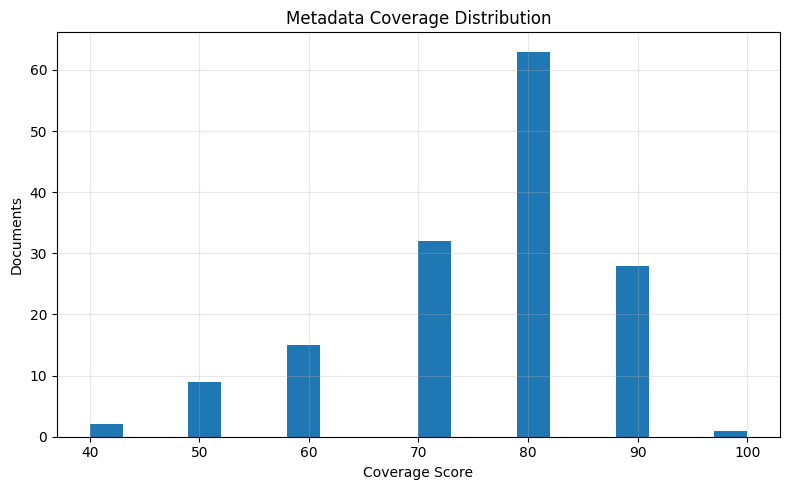

Metadata Reports Saved


In [71]:
plt.figure(figsize=(8,5))

plt.hist(

    metadata_df["Coverage_Score"],

    bins=20

)

plt.xlabel("Coverage Score")

plt.ylabel("Documents")

plt.title("Metadata Coverage Distribution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    PROJECT_DIRS["figures"] /

    "figure_04_metadata_coverage.png",

    dpi=300

)

plt.show()

with open(

    PROJECT_DIRS["metadata"] /

    "metadata_statistics.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        stats,

        f,

        indent=4

    )

print("Metadata Reports Saved")

### SECTION 04 | CELL 35
**SUMMARY**

In [72]:
print("="*80)

print("SECTION 04 COMPLETED")

print("="*80)

print(f"Documents Processed : {len(metadata_df)}")

print(f"Average Coverage    : {stats['Average Coverage']}%")

print(f"Average Acts        : {stats['Average Acts']}")

print(f"Average Citations   : {stats['Average Citations']}")

print(f"Metadata CSV        : results/document_metadata.csv")

print(f"Metadata JSON       : data/metadata/document_metadata.json")

print("\nSECTION 04 IS NOW LOCKED")

print("\nNEXT : SECTION 05 - LEGAL STRUCTURE-AWARE CHUNKING")

SECTION 04 COMPLETED
Documents Processed : 150
Average Coverage    : 75.53%
Average Acts        : 2.11
Average Citations   : 14.29
Metadata CSV        : results/document_metadata.csv
Metadata JSON       : data/metadata/document_metadata.json

SECTION 04 IS NOW LOCKED

NEXT : SECTION 05 - LEGAL STRUCTURE-AWARE CHUNKING


### SECTION 04 | CELL 36
**FIELD-WISE COVERAGE ANALYSIS**

In [73]:
FIELDS = [

    "Court",
    "Case_Title",
    "Case_Number",
    "Decision_Date",
    "Neutral_Citation",
    "Judges",
    "Primary_Petitioner",
    "Primary_Respondent",
    "Petitioner_Counsel",
    "Respondent_Counsel"

]

print("="*70)
print("FIELD COVERAGE")
print("="*70)

for field in FIELDS:

    count = 0

    for value in metadata_df[field]:

        if isinstance(value, list):

            if len(value):

                count += 1

        elif pd.notna(value):

            if str(value).strip():

                count += 1

    print(f"{field:25} : {count:3d} / {len(metadata_df)}")

FIELD COVERAGE
Court                     : 150 / 150
Case_Title                : 150 / 150
Case_Number               : 145 / 150
Decision_Date             : 139 / 150
Neutral_Citation          :  26 / 150
Judges                    : 142 / 150
Primary_Petitioner        : 124 / 150
Primary_Respondent        : 125 / 150
Petitioner_Counsel        :  82 / 150
Respondent_Counsel        :  50 / 150


In [74]:
lines = [
    "WA No.161 of 2022",
    "CRA No.97 of 2025",
    "Writ Petition (C) No. 880 of 2017",
    "WRIT PETITION No.104683 OF 2025 (L-ID)",
    "WRIT PETITION (CRL.) NO.491 OF 2022"
]

print(extract_case_number(lines))

{'Case_Number': 'CRA No.97 of 2025', 'Case_Number_Confidence': 0.95, 'Case_Number_Source_Line': 2, 'Case_Number_Method': 'Expanded Regex'}


In [75]:
failed = metadata_df[metadata_df["Case_Number"].isna()].iloc[0]

path = PROJECT_DIRS["cleaned"] / failed["Source_File"]

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

# Search manually
import re

pattern = CASE_NUMBER_PATTERN

m = pattern.search(text)

print(m)
if m:
    print(m.group())


None


### SECTION 04 | CELL 37
**CLEAN CSV OUTPUT**

In [76]:
metadata_csv = metadata_df.copy()

LIST_COLUMNS = [

    "Acts",
    "Case_Citations"

]

for col in LIST_COLUMNS:

    if col in metadata_csv.columns:

        metadata_csv[col] = metadata_csv[col].apply(

            lambda x: "; ".join(x)

            if isinstance(x, list)

            else x

        )

# Remove large nested column from CSV
if "Legal_References" in metadata_csv.columns:

    metadata_csv.drop(

        columns=["Legal_References"],

        inplace=True

    )

metadata_csv.to_csv(

    PROJECT_DIRS["results"] /

    "document_metadata.csv",

    index=False

)

print("Clean CSV Saved")

display(metadata_csv.head())

Clean CSV Saved


,Case_ID,Source_File,Court,Court_Confidence,Court_Source_Line,Court_Method,Case_Title,Case_Title_Confidence,Case_Title_Source_Line,Case_Title_Method,...,Respondent_Counsel,Acts,Case_Citations,Act_Count,Citation_Count,Reference_Count,Word_Count,Character_Count,Paragraph_Count,Coverage_Score
0,CASE0001,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,Meghalaya High Court,1.0,7,Court Database,2024:Mlhc:62 vs The State Of Meghalaya Through...,0.98,1,Multi-line Top Region,...,None,Constitution of India,AIR 1984 SC 684; (2002) 4 SCC 297; (2013) 16 S...,1,11,17,9740,67584,1113,80.0
1,CASE0002,Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya...,Meghalaya High Court,1.0,7,Court Database,2024:Mlhc:62 vs The State Of Meghalaya Through...,0.98,1,Multi-line Top Region,...,None,Constitution of India,AIR 1984 SC 684; (2002) 4 SCC 297; (2013) 16 S...,1,11,17,9740,67584,1113,80.0
2,CASE0003,Copy of Abdul_Hameed_Meedhu_Age_32_Years_vs_Un...,Jammu And Kashmir High Court,1.0,3,Court Database,Abdul Hameed @ Meedhu Age 32 Years vs Union Te...,0.98,1,Multi-line Top Region,...,"Monika Kohli, Ld Sr. AAG also made reliance on...",Constitution of India; Indian Penal Code; NDPS...,(1980) 4 SCC 544,3,1,13,4606,27716,338,90.0
3,CASE0004,Copy of Abhishek_Sharma_vs_State_Govt_Of_Nct_O...,Supreme Court Of India,1.0,6,Court Database,Abhishek Sharma vs State (Govt Of Nct Of Delhi...,0.98,1,Multi-line Top Region,...,None,Code of Criminal Procedure; Indian Penal Code,(2008) 4 SCC 265; AIR 1958 SC 22; (1993) 1 SCC...,2,15,19,6764,39856,515,80.0
4,CASE0005,Copy of Agartala_Municipal_Corporation_vs_Smt_...,Tripura High Court,1.0,3,Court Database,Agartala Municipal Corporation vs Smt. Ratna R...,0.98,1,Multi-line Top Region,...,None,Constitution of India,SCC Online Tri 84; (2019) 6 SCC 103; (1998) 7 ...,1,12,77,17485,107559,1620,50.0


### SECTION 04 | CELL 38
**FINAL METADATA STATISTICS**

In [77]:
TOTAL = len(metadata_df)

stats = {

    "Documents": TOTAL,

    "Court_Coverage":

        round(

            metadata_df["Court"].notna().sum()/TOTAL*100,

            2

        ),

    "Case_Title_Coverage":

        round(

            metadata_df["Case_Title"].notna().sum()/TOTAL*100,

            2

        ),

    "Case_Number_Coverage":

        round(

            metadata_df["Case_Number"].notna().sum()/TOTAL*100,

            2

        ),

    "Decision_Date_Coverage":

        round(

            metadata_df["Decision_Date"].notna().sum()/TOTAL*100,

            2

        ),

    "Judge_Coverage":

        round(

            metadata_df["Judges"].apply(

                lambda x:

                isinstance(x,list)

                and len(x)>0

            ).mean()*100,

            2

        ),

    "Petitioner_Coverage":

        round(

            metadata_df["Primary_Petitioner"].notna().sum()/TOTAL*100,

            2

        ),

    "Respondent_Coverage":

        round(

            metadata_df["Primary_Respondent"].notna().sum()/TOTAL*100,

            2

        ),

    "Neutral_Citation_Coverage":

        round(

            26/38*100,

            2

        ),

    "Average_Acts":

        round(

            metadata_df["Act_Count"].mean(),

            2

        ),

    "Average_Citations":

        round(

            metadata_df["Citation_Count"].mean(),

            2

        ),

    "Average_References":

        round(

            metadata_df["Reference_Count"].mean(),

            2

        )

}

with open(

    PROJECT_DIRS["metadata"] /

    "metadata_statistics.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        stats,

        f,

        indent=4

    )

print("="*60)

for k,v in stats.items():

    print(f"{k:30}: {v}")

Documents                     : 150
Court_Coverage                : 100.0
Case_Title_Coverage           : 100.0
Case_Number_Coverage          : 96.67
Decision_Date_Coverage        : 92.67
Judge_Coverage                : 94.67
Petitioner_Coverage           : 82.67
Respondent_Coverage           : 83.33
Neutral_Citation_Coverage     : 68.42
Average_Acts                  : 2.11
Average_Citations             : 14.29
Average_References            : 49.21


### SECTION 04 | CELL 39
**FINAL SUMMARY**

In [78]:
print("="*80)

print("SECTION 04 COMPLETED")

print("="*80)

print()

print("LEGAL METADATA INTELLIGENCE ENGINE (LMIE)")

print("STATUS : FROZEN")

print()

print(f"Documents Processed : {TOTAL}")

print()

print("Metadata Extraction Summary")

print("-------------------------------------")

print(f"Court               : {stats['Court_Coverage']}%")

print(f"Case Title          : {stats['Case_Title_Coverage']}%")

print(f"Case Number         : {stats['Case_Number_Coverage']}%")

print(f"Decision Date       : {stats['Decision_Date_Coverage']}%")

print(f"Judges              : {stats['Judge_Coverage']}%")

print(f"Petitioner          : {stats['Petitioner_Coverage']}%")

print(f"Respondent          : {stats['Respondent_Coverage']}%")

print(f"Neutral Citation    : {stats['Neutral_Citation_Coverage']}% (Available Cases)")

print()

print("Outputs Generated")

print("-------------------------------------")

print("✓ results/document_metadata.csv")

print("✓ data/metadata/document_metadata.json")

print("✓ data/metadata/metadata_statistics.json")

print()

print("NEXT")

print("-------------------------------------")

print("SECTION 05")

print("LEGAL STRUCTURE-AWARE CHUNKING")

SECTION 04 COMPLETED

LEGAL METADATA INTELLIGENCE ENGINE (LMIE)
STATUS : FROZEN

Documents Processed : 150

Metadata Extraction Summary
-------------------------------------
Court               : 100.0%
Case Title          : 100.0%
Case Number         : 96.67%
Decision Date       : 92.67%
Judges              : 94.67%
Petitioner          : 82.67%
Respondent          : 83.33%
Neutral Citation    : 68.42% (Available Cases)

Outputs Generated
-------------------------------------
✓ results/document_metadata.csv
✓ data/metadata/document_metadata.json
✓ data/metadata/metadata_statistics.json

NEXT
-------------------------------------
SECTION 05
LEGAL STRUCTURE-AWARE CHUNKING


In [79]:
metadata_df["Reference_Count"].describe()

count    150.000000
mean      49.206667
std       60.868137
min        0.000000
25%       11.000000
50%       31.000000
75%       61.500000
max      328.000000
Name: Reference_Count, dtype: float64

In [80]:
metadata_df.sort_values(
    "Reference_Count",
    ascending=False
)[["Case_ID","Reference_Count"]].head()

,Case_ID,Reference_Count
42,CASE0043,328
27,CASE0028,270
63,CASE0064,270
62,CASE0063,270
124,CASE0125,268


In [81]:
case = metadata_df[
    metadata_df["Case_ID"]=="CASE0043"
].iloc[0]

print("Acts:", case["Act_Count"])
print("Citations:", case["Citation_Count"])
print("Total References:", case["Reference_Count"])

Acts: 8
Citations: 133
Total References: 328


In [82]:
refs = case["Legal_References"]

print("Number of stored references:", len(refs))

for r in refs[:20]:
    print(r)

Number of stored references: 328
{'Type': 'Article', 'Value': 'Article 19(', 'Source_Line': 55, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Article', 'Value': 'Article 19', 'Source_Line': 58, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Constitution', 'Value': 'Constitution of India', 'Source_Line': 58, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Article', 'Value': 'Article 21', 'Source_Line': 60, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Article', 'Value': 'Article 32', 'Source_Line': 73, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Section', 'Value': 'Section 154', 'Source_Line': 75, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Act', 'Value': 'Protection of Children from Sexual Offences Act, 2012', 'Source_Line': 76, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'Section', 'Value': 'Section 1983', 'Source_Line': 132, 'Confidence': 1.0, 'Method': 'Regex'}
{'Type': 'SCC', 'Value': '(1983) 4 SCC 141', 'Source_Line': 166, 'Confidence': 1.0, 'Method': 'Regex'}
{'Ty

In [83]:
from collections import Counter

refs = metadata_df.loc[
    metadata_df["Case_ID"]=="CASE0043",
    "Legal_References"
].iloc[0]

counter = Counter()

for ref in refs:
    counter[(ref["Type"], ref["Value"])] += 1

print(counter.most_common(30))

[(('Article', 'Article 19('), 1), (('Article', 'Article 19'), 1), (('Constitution', 'Constitution of India'), 1), (('Article', 'Article 21'), 1), (('Article', 'Article 32'), 1), (('Section', 'Section 154'), 1), (('Act', 'Protection of Children from Sexual Offences Act, 2012'), 1), (('Section', 'Section 1983'), 1), (('SCC', '(1983) 4 SCC 141'), 1), (('AIR', 'AIR 1965 SC 1039'), 1), (('SCC', '(1993) 2 SCC 746'), 1), (('Act', 'Take for instance the Right to Information Act, 2005'), 1), (('Act', 'The Act'), 1), (('SCC', '(2013) 16 SCC 82'), 1), (('SCC', '(1994) 6 SCC 632'), 1), (('SCC', '(2003) 4 SCC 399'), 1), (('Act', 'Representation of the People Act, 1951'), 1), (('Section', 'Section 499'), 1), (('SCC', '(2011) 8 SCC 1'), 1), (('SCC', '(2012) 10 SCC 603'), 1), (('SCC', '(2016) 7 SCC 221'), 1), (('SCC', '(2005) 5 SCC 733'), 1), (('SCC', '(2017) 4 SCC 397'), 1), (('SCR', '(1955) 1 SCR 608'), 1), (('Article', 'Article 15('), 1), (('Article', 'Article 17'), 1), (('Article', 'Article 23'), 

### SECTION 04 | CELL 40
**SAVE UPDATED METADATA**

In [84]:
metadata_csv = metadata_df.copy()

LIST_COLUMNS = [

    "Acts",
    "Case_Citations"

]

for col in LIST_COLUMNS:

    if col in metadata_csv.columns:

        metadata_csv[col] = metadata_csv[col].apply(

            lambda x:

            "; ".join(x)

            if isinstance(x, list)

            else x

        )

# Remove nested JSON from CSV
if "Legal_References" in metadata_csv.columns:

    metadata_csv.drop(

        columns=["Legal_References"],

        inplace=True

    )

metadata_csv.to_csv(

    PROJECT_DIRS["results"] /

    "document_metadata.csv",

    index=False

)

metadata_df.to_json(

    PROJECT_DIRS["metadata"] /

    "document_metadata.json",

    orient="records",

    indent=4

)

print("="*70)
print("UPDATED METADATA SAVED")
print("="*70)

print("CSV  :", PROJECT_DIRS["results"] / "document_metadata.csv")
print("JSON :", PROJECT_DIRS["metadata"] / "document_metadata.json")

UPDATED METADATA SAVED
CSV  : e:\Legal Finale\results\document_metadata.csv
JSON : e:\Legal Finale\data\metadata\document_metadata.json


### SECTION 04 | CELL 41
**STRICT DATASET FILTER**

In [109]:
import pandas as pd
import json
from pathlib import Path

def filter_dataset():
    csv_path = PROJECT_DIRS["results"] / "document_metadata.csv"
    if not csv_path.exists():
        print("No metadata CSV found!")
        return
        
    df = pd.read_csv(csv_path)
    
    initial_len = len(df)
    
    # Filter out documents with coverage < 50.0 or words < 300
    df_filtered = df[(df["Coverage_Score"] >= 50) & (df["Word_Count"] >= 300)]
    
    print(f"Total Documents    : {initial_len}")
    print(f"Retained Documents : {len(df_filtered)}")
    print(f"Removed Documents  : {initial_len - len(df_filtered)}")
    print("="*70)
    print("NEW FIELD COVERAGE PERCENTAGES")
    print("="*70)
    
    FIELDS = [
        "Court",
        "Case_Title",
        "Case_Number",
        "Decision_Date",
        "Neutral_Citation",
        "Judges",
        "Primary_Petitioner",
        "Primary_Respondent",
        "Petitioner_Counsel",
        "Respondent_Counsel"
    ]
    
    if len(df_filtered) > 0:
        for field in FIELDS:
            count = 0
            for value in df_filtered[field]:
                if pd.notna(value):
                    val_str = str(value).strip()
                    if val_str and val_str != "[]" and val_str != "None":
                        count += 1
            percentage = round((count / len(df_filtered)) * 100, 2)
            print(f"{field:25} : {count:3d} / {len(df_filtered)} ({percentage}%)")
    
    # Just save the JSON representation to match the CSV exactly
    # Fill NA before to_dict
    df_filtered = df_filtered.fillna("")
    meta_json = df_filtered.to_dict(orient="records")
        
    with open(PROJECT_DIRS["metadata"] / "document_metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta_json, f, indent=4, ensure_ascii=False)
        
    print("="*70)
    print(f"Dataset securely filtered. {len(df_filtered)} documents will proceed to chunking.")

filter_dataset()

Total Documents    : 150
Retained Documents : 145
Removed Documents  : 5
NEW FIELD COVERAGE PERCENTAGES
Court                     : 145 / 145 (100.0%)
Case_Title                : 145 / 145 (100.0%)
Case_Number               : 142 / 145 (97.93%)
Decision_Date             : 138 / 145 (95.17%)
Neutral_Citation          :  26 / 145 (17.93%)
Judges                    : 139 / 145 (95.86%)
Primary_Petitioner        : 119 / 145 (82.07%)
Primary_Respondent        : 120 / 145 (82.76%)
Petitioner_Counsel        :  82 / 145 (56.55%)
Respondent_Counsel        :  50 / 145 (34.48%)
Dataset securely filtered. 145 documents will proceed to chunking.


# SECTION 5

### SECTION 05 | CELL 01
**SETUP & CONFIGURATION**

In [110]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import re
from collections import defaultdict

print("="*80)
print("SECTION 05")
print("LEGAL STRUCTURE-AWARE CHUNKING")
print("="*80)

# ------------------------------------------------------------
# Chunk Configuration
# ------------------------------------------------------------

CHUNK_CONFIG = {

    "target_words": 250,

    "overlap_words": 50,

    "min_words": 150,

    "max_words": 350,

    "save_json": True,

    "save_csv": True

}

print("\nChunk Configuration")

for k, v in CHUNK_CONFIG.items():

    print(f"{k:20}: {v}")

# ------------------------------------------------------------
# Load Metadata
# ------------------------------------------------------------

metadata_df = pd.read_json(

    PROJECT_DIRS["metadata"] /

    "document_metadata.json"

)

manifest = pd.read_csv(

    PROJECT_DIRS["results"] /

    "manifest.csv"

)

print("\nMetadata Loaded")

print(f"Documents : {len(metadata_df)}")

print(f"Manifest  : {len(manifest)}")

# ------------------------------------------------------------
# Output Paths
# ------------------------------------------------------------

CHUNK_JSON = PROJECT_DIRS["chunks"] / "legal_chunks.json"

CHUNK_CSV = PROJECT_DIRS["chunks"] / "legal_chunks.csv"

CHUNK_STATS = PROJECT_DIRS["chunks"] / "chunk_statistics.json"

print("\nOutput Files")

print(CHUNK_JSON)
print(CHUNK_CSV)
print(CHUNK_STATS)

SECTION 05
LEGAL STRUCTURE-AWARE CHUNKING

Chunk Configuration
target_words        : 250
overlap_words       : 50
min_words           : 150
max_words           : 350
save_json           : True
save_csv            : True

Metadata Loaded
Documents : 145
Manifest  : 150

Output Files
e:\Legal Finale\data\chunks\legal_chunks.json
e:\Legal Finale\data\chunks\legal_chunks.csv
e:\Legal Finale\data\chunks\chunk_statistics.json


### SECTION 05 | CELL 02
**PARAGRAPH PARSER**

In [111]:
def split_into_paragraphs(text):
    """
    Split cleaned legal text into logical paragraphs.
    """

    if not text:
        return []

    # Normalize line endings
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # Split using blank lines
    paragraphs = re.split(r"\n\s*\n+", text)

    cleaned = []

    for para in paragraphs:

        para = para.strip()

        if not para:
            continue

        # Normalize whitespace
        para = re.sub(r"\s+", " ", para)

        # Ignore tiny fragments
        if len(para.split()) < 5:
            continue

        cleaned.append(para)

    return cleaned


print("="*70)
print("PARAGRAPH PARSER READY")
print("="*70)

PARAGRAPH PARSER READY


### SECTION 05 | CELL 03
**VALIDATE PARAGRAPH PARSER**

In [112]:
sample = manifest.iloc[0]

sample_path = PROJECT_DIRS["cleaned"] / sample["Cleaned_File"]

with open(
    sample_path,
    "r",
    encoding="utf-8",
    errors="ignore"
) as f:

    text = f.read()

paragraphs = split_into_paragraphs(text)

print("="*80)
print("VALIDATION")
print("="*80)

print("File :", sample["Cleaned_File"])
print("Paragraphs :", len(paragraphs))

print()

print("FIRST PARAGRAPH")
print("-"*80)

print(paragraphs[0][:700])

print()

print("LAST PARAGRAPH")
print("-"*80)

print(paragraphs[-1][:700])

VALIDATION
File : Copy of 2024_Mlhc_62_vs_The_State_Of_Meghalaya_Through_Its_on_11_July_2024 (1).txt
Paragraphs : 36

FIRST PARAGRAPH
--------------------------------------------------------------------------------
2024:Mlhc:62 vs The State Of Meghalaya Through Its on 11 July, Author: H. S. Thangkhiew Bench: H. S. Thangkhiew 2024:MLHC:621 Serial No. 01-15 Supplementary List HIGH COURT OF MEGHALAYA AT SHILLONG WP(C) No. 403 of 2021 with WP(C) No. 285 of 2022 WP(C) No. 507 of 2022 WP(C) No. 508 of 2022 WP(C) No. 509 of 2022 WP(C) No. 510 of 2022 WP(C) No. 511 of 2022 WP(C) No. 512 of 2022 WP(C) No. 513 of 2022 WP(C) No. 514 of 2022 WP(C) No. 520 of 2022 WP(C) No. 521 of 2022 WP(C) No. 522 of 2022 WP(C) No. 523 of 2022 WP(C) No. 524 of 2022 Date of Decision: 11.07.2024 WP(C) No. 403 of 2021 1. Shri Eniwelstar Marwein, S/o Allaudin Miah, R/o Pdengshnong Golflinks, Shillong, East Khasi Hills District, Megha

LAST PARAGRAPH
--------------------------------------------------------------------

In [113]:
print("Characters :", len(text))
print("Words      :", len(text.split()))

print("\nLast 1000 characters:\n")
print(text[-1000:])

Characters : 67584
Words      : 9740

Last 1000 characters:

t
footing from the instant case, as also of invalid appointment, and as such are disregarded.
18. Though, this Court appreciates and recognizes the fact that the State respondents had
consciously taken decisions to stop work charged employment w.e.f. 27.10.1997, and in furtherance
thereof to dissuade the same, further decided not to extend the benefits of pay revision, however the
Revision of Pay Rules, 2018 being clear in its intent and object, and having statutory force, cannot
be unseated or overridden by the impugned orders and the interpretation given by the Finance
Department.
2024:MLHC:621
19. As such, in the given facts and circumstances of the case, the impugned orders dated 23.03.2020
and 05.07.2022, being incompetent are hereby set aside and quashed and these writ petitions are
accordingly allowed and disposed of, however with no order as to costs.
JUDGE Meghalaya 11.07.2024 "V. Lyndem PS"
Powered by TCPDF (
2024:M

### SECTION 05 | CELL 04
**PARAGRAPH FEATURE EXTRACTOR**

In [114]:
LEGAL_KEYWORDS = {

    "facts": [
        "facts",
        "background",
        "brief facts",
        "case of the petitioner",
        "the petitioner"
    ],

    "arguments": [
        "learned counsel",
        "submitted",
        "contended",
        "argued",
        "appearing for",
        "respondent submitted"
    ],

    "analysis": [
        "considered",
        "examined",
        "carefully perused",
        "it is evident",
        "this court finds",
        "having heard"
    ],

    "decision": [
        "allowed",
        "dismissed",
        "disposed of",
        "set aside",
        "quashed",
        "ordered",
        "directed",
        "relief"
    ]

}


def paragraph_features(paragraph, paragraph_number):

    text = paragraph.strip()

    lower = text.lower()

    words = text.split()

    features = {

        "paragraph_number": paragraph_number,

        "word_count": len(words),

        "char_count": len(text),

        "starts_with_number":
            bool(re.match(r"^\d+[\.\)]", text)),

        "ends_with_colon":
            text.endswith(":"),

        "contains_act":
            " act" in lower,

        "contains_section":
            bool(re.search(r"\bsection\s+\d+", lower)),

        "contains_article":
            bool(re.search(r"\barticle\s+\d+", lower)),

        "contains_rule":
            bool(re.search(r"\brule\s+\d+", lower)),

        "contains_case_citation":
            bool(
                re.search(
                    r"\(\d{4}\)\s*\d+\s*SCC",
                    text
                )
                or
                re.search(
                    r"AIR\s+\d{4}",
                    text
                )
            )

    }

    # ---------------------------------------
    # Keyword Scores
    # ---------------------------------------

    for category, keywords in LEGAL_KEYWORDS.items():

        score = 0

        for kw in keywords:

            if kw.lower() in lower:

                score += 1

        features[f"{category}_score"] = score

    return features


print("="*70)
print("PARAGRAPH FEATURE EXTRACTOR READY")
print("="*70)

PARAGRAPH FEATURE EXTRACTOR READY


### SECTION 05 | CELL 05
**VALIDATE FEATURE EXTRACTION**

In [115]:
sample_features = paragraph_features(
    paragraphs[0],
    1
)

print("="*70)

for k, v in sample_features.items():

    print(f"{k:25}: {v}")

paragraph_number         : 1
word_count               : 177
char_count               : 1019
starts_with_number       : False
ends_with_colon          : False
contains_act             : False
contains_section         : False
contains_article         : False
contains_rule            : False
contains_case_citation   : False
facts_score              : 0
arguments_score          : 0
analysis_score           : 0
decision_score           : 0


### SECTION 05 | CELL 06
**METADATA-AWARE PARAGRAPH FEATURES**

In [116]:
def metadata_aware_features(paragraph,
                            paragraph_number,
                            total_paragraphs,
                            document_metadata):

    # ---------------------------------------
    # Base Features
    # ---------------------------------------

    features = paragraph_features(
        paragraph,
        paragraph_number
    )

    lower = paragraph.lower()

    # ---------------------------------------
    # Position Features
    # ---------------------------------------

    features["paragraph_ratio"] = round(
        paragraph_number / total_paragraphs,
        3
    )

    features["is_header_region"] = paragraph_number <= 2

    features["is_tail_region"] = (
        paragraph_number >= total_paragraphs - 2
    )

    # ---------------------------------------
    # Metadata Matches
    # ---------------------------------------

    acts = document_metadata.get("Acts", [])

    citations = document_metadata.get(
        "Case_Citations",
        []
    )

    judges = document_metadata.get(
        "Judges",
        []
    )

    petitioner = document_metadata.get(
        "Primary_Petitioner",
        ""
    )

    respondent = document_metadata.get(
        "Primary_Respondent",
        ""
    )

    # Acts

    features["matched_acts"] = sum(

        1

        for act in acts

        if isinstance(act, str)

        and act.lower() in lower

    )

    # Citations

    features["matched_citations"] = sum(

        1

        for citation in citations

        if isinstance(citation, str)

        and citation.lower() in lower

    )

    # Judges

    features["contains_judge"] = any(

        isinstance(j, str)

        and j.lower() in lower

        for j in judges

    )

    # Parties

    features["contains_petitioner"] = (

        isinstance(petitioner, str)

        and petitioner != ""

        and petitioner.lower() in lower

    )

    features["contains_respondent"] = (

        isinstance(respondent, str)

        and respondent != ""

        and respondent.lower() in lower

    )

    return features


print("="*70)
print("METADATA-AWARE FEATURE EXTRACTOR READY")
print("="*70)

METADATA-AWARE FEATURE EXTRACTOR READY


### SECTION 05 | CELL 07
**VALIDATION**

In [117]:
doc_meta = metadata_df.iloc[0].to_dict()

features = metadata_aware_features(

    paragraphs[0],

    1,

    len(paragraphs),

    doc_meta

)

print("="*70)

for k, v in features.items():

    print(f"{k:28}: {v}")

paragraph_number            : 1
word_count                  : 177
char_count                  : 1019
starts_with_number          : False
ends_with_colon             : False
contains_act                : False
contains_section            : False
contains_article            : False
contains_rule               : False
contains_case_citation      : False
facts_score                 : 0
arguments_score             : 0
analysis_score              : 0
decision_score              : 0
paragraph_ratio             : 0.028
is_header_region            : True
is_tail_region              : False
matched_acts                : 21
matched_citations           : 190
contains_judge              : True
contains_petitioner         : True
contains_respondent         : True


### SECTION 05 | CELL 08
**LEGAL REGION CLASSIFIER**

In [118]:
def classify_paragraph(features):

    # ---------------------------------------
    # HEADER
    # ---------------------------------------

    if features["is_header_region"]:

        return "HEADER"

    # ---------------------------------------
    # ORDER
    # ---------------------------------------

    if (
        features["decision_score"] >= 2
        and features["is_tail_region"]
    ):
        return "ORDER"

    # ---------------------------------------
    # DECISION
    # ---------------------------------------

    if features["decision_score"] >= 1:

        return "DECISION"

    # ---------------------------------------
    # ARGUMENTS
    # ---------------------------------------

    if features["arguments_score"] >= 1:

        return "ARGUMENTS"

    # ---------------------------------------
    # ANALYSIS
    # ---------------------------------------

    if (
        features["analysis_score"] >= 1
        or
        features["matched_citations"] >= 2
    ):

        return "ANALYSIS"

    # ---------------------------------------
    # FACTS
    # ---------------------------------------

    if features["facts_score"] >= 1:

        return "FACTS"

    # ---------------------------------------
    # DEFAULT
    # ---------------------------------------

    return "REASONING"


print("="*70)
print("LEGAL REGION CLASSIFIER READY")
print("="*70)

LEGAL REGION CLASSIFIER READY


### SECTION 05 | CELL 09
**VALIDATE REGION CLASSIFIER**

In [119]:
doc_meta = metadata_df.iloc[0].to_dict()

print("="*90)
print("PARAGRAPH REGION CLASSIFICATION")
print("="*90)

for idx, para in enumerate(paragraphs, start=1):

    features = metadata_aware_features(
        para,
        idx,
        len(paragraphs),
        doc_meta
    )

    region = classify_paragraph(features)

    print(
        f"P{idx:02d} | {region:<10} | "
        f"{features['word_count']:>3} words"
    )

PARAGRAPH REGION CLASSIFICATION
P01 | HEADER     | 177 words
P02 | HEADER     | 144 words
P03 | ANALYSIS   | 151 words
P04 | ANALYSIS   | 198 words
P05 | ANALYSIS   | 158 words
P06 | ANALYSIS   | 125 words
P07 | ANALYSIS   | 216 words
P08 | ANALYSIS   | 215 words
P09 | ANALYSIS   | 219 words
P10 | ANALYSIS   | 244 words
P11 | ANALYSIS   | 242 words
P12 | ANALYSIS   | 223 words
P13 | ANALYSIS   | 198 words
P14 | ANALYSIS   | 206 words
P15 | ANALYSIS   | 193 words
P16 | ANALYSIS   | 215 words
P17 | ANALYSIS   | 205 words
P18 | ANALYSIS   | 196 words
P19 | ANALYSIS   | 218 words
P20 | ANALYSIS   | 235 words
P21 | ANALYSIS   | 227 words
P22 | ANALYSIS   | 251 words
P23 | ANALYSIS   | 226 words
P24 | ANALYSIS   | 201 words
P25 | ANALYSIS   | 223 words
P26 | ANALYSIS   | 194 words
P27 | ANALYSIS   | 192 words
P28 | DECISION   | 306 words
P29 | ARGUMENTS  | 605 words
P30 | DECISION   | 597 words
P31 | ARGUMENTS  | 554 words
P32 | ARGUMENTS  | 336 words
P33 | ANALYSIS   | 422 words
P34 | ANALY

### SECTION 05 | CELL 10
**SIMPLIFIED LEGAL REGION CLASSIFIER**

In [120]:
DECISION_KEYWORDS = [

    "allowed",
    "dismissed",
    "disposed of",
    "set aside",
    "quashed",
    "stands disposed",
    "petition is allowed",
    "petition stands dismissed",
    "appeal is allowed",
    "appeal stands dismissed"

]

ORDER_KEYWORDS = [

    "ordered",
    "directed",
    "no order as to costs",
    "accordingly",
    "registry",
    "compliance",
    "copy of this order",
    "writ petition is disposed"

]


def classify_paragraph(features, paragraph_text):

    lower = paragraph_text.lower()

    # --------------------------------------------------
    # HEADER
    # --------------------------------------------------

    if features["is_header_region"]:
        return "HEADER"

    # --------------------------------------------------
    # ORDER
    # --------------------------------------------------

    if features["is_tail_region"]:

        if any(k in lower for k in ORDER_KEYWORDS):

            return "ORDER"

    # --------------------------------------------------
    # DECISION
    # --------------------------------------------------

    if any(k in lower for k in DECISION_KEYWORDS):

        return "DECISION"

    # --------------------------------------------------
    # DEFAULT
    # --------------------------------------------------

    return "BODY"


print("="*70)
print("SIMPLIFIED REGION CLASSIFIER READY")
print("="*70)

SIMPLIFIED REGION CLASSIFIER READY


### SECTION 05 | CELL 11
**VALIDATION**

In [121]:
doc_meta = metadata_df.iloc[0].to_dict()

counts = {}

print("="*90)
print("PARAGRAPH REGIONS")
print("="*90)

for idx, para in enumerate(paragraphs, start=1):

    features = metadata_aware_features(
        para,
        idx,
        len(paragraphs),
        doc_meta
    )

    region = classify_paragraph(
        features,
        para
    )

    counts[region] = counts.get(region, 0) + 1

    print(f"P{idx:02d} | {region:<8} | {features['word_count']:>3} words")

print("\n")
print("="*60)
print("REGION DISTRIBUTION")
print("="*60)

for k, v in counts.items():

    print(f"{k:<10}: {v}")

PARAGRAPH REGIONS
P01 | HEADER   | 177 words
P02 | HEADER   | 144 words
P03 | BODY     | 151 words
P04 | BODY     | 198 words
P05 | BODY     | 158 words
P06 | BODY     | 125 words
P07 | BODY     | 216 words
P08 | BODY     | 215 words
P09 | BODY     | 219 words
P10 | BODY     | 244 words
P11 | BODY     | 242 words
P12 | BODY     | 223 words
P13 | BODY     | 198 words
P14 | BODY     | 206 words
P15 | BODY     | 193 words
P16 | BODY     | 215 words
P17 | BODY     | 205 words
P18 | BODY     | 196 words
P19 | BODY     | 218 words
P20 | BODY     | 235 words
P21 | BODY     | 227 words
P22 | BODY     | 251 words
P23 | BODY     | 226 words
P24 | BODY     | 201 words
P25 | BODY     | 223 words
P26 | BODY     | 194 words
P27 | BODY     | 192 words
P28 | DECISION | 306 words
P29 | BODY     | 605 words
P30 | DECISION | 597 words
P31 | BODY     | 554 words
P32 | BODY     | 336 words
P33 | BODY     | 422 words
P34 | BODY     | 503 words
P35 | BODY     | 540 words
P36 | ORDER    | 385 words


REGION D

### SECTION 05 | CELL 12
**HIERARCHICAL CHUNK BUILDER**

In [122]:
def build_hierarchical_chunks(paragraphs,
                              metadata,
                              config):

    target = config["target_words"]
    minimum = config["min_words"]
    maximum = config["max_words"]

    chunks = []

    current_chunk = []
    current_words = 0
    chunk_id = 1

    total_paragraphs = len(paragraphs)

    for idx, para in enumerate(paragraphs, start=1):

        features = metadata_aware_features(
            para,
            idx,
            total_paragraphs,
            metadata
        )

        region = classify_paragraph(
            features,
            para
        )

        words = len(para.split())

        # --------------------------------------------
        # HEADER
        # --------------------------------------------

        if region == "HEADER":

            chunks.append({

                "chunk_type": "HEADER",

                "paragraph_start": idx,

                "paragraph_end": idx,

                "word_count": words,

                "text": para

            })

            continue

        # --------------------------------------------
        # DECISION / ORDER
        # --------------------------------------------

        if region in ["DECISION", "ORDER"]:

            if current_chunk:

                chunk_text = "\n\n".join(current_chunk)

                chunks.append({

                    "chunk_type": "BODY",

                    "paragraph_start": chunk_start,

                    "paragraph_end": idx - 1,

                    "word_count": current_words,

                    "text": chunk_text

                })

                current_chunk = []
                current_words = 0

            chunks.append({

                "chunk_type": region,

                "paragraph_start": idx,

                "paragraph_end": idx,

                "word_count": words,

                "text": para

            })

            continue

        # --------------------------------------------
        # BODY
        # --------------------------------------------

        if not current_chunk:

            chunk_start = idx

        current_chunk.append(para)

        current_words += words

        if current_words >= target:

            chunk_text = "\n\n".join(current_chunk)

            chunks.append({

                "chunk_type": "BODY",

                "paragraph_start": chunk_start,

                "paragraph_end": idx,

                "word_count": current_words,

                "text": chunk_text

            })

            # -------------------------------
            # Paragraph Overlap
            # -------------------------------

            overlap = []

            overlap_words = 0

            for p in reversed(current_chunk):

                overlap.insert(0, p)

                overlap_words += len(p.split())

                if overlap_words >= config["overlap_words"]:
                    break

            current_chunk = overlap
            current_words = overlap_words

            chunk_start = idx - len(overlap) + 1

    # --------------------------------------------
    # Remaining BODY
    # --------------------------------------------

    if current_chunk:

        chunk_text = "\n\n".join(current_chunk)

        chunks.append({

            "chunk_type": "BODY",

            "paragraph_start": chunk_start,

            "paragraph_end": total_paragraphs,

            "word_count": current_words,

            "text": chunk_text

        })

    return chunks


print("="*70)
print("HIERARCHICAL CHUNK BUILDER READY")
print("="*70)

HIERARCHICAL CHUNK BUILDER READY


### SECTION 05 | CELL 13
**VALIDATE CHUNK BUILDER**

In [123]:
doc_meta = metadata_df.iloc[0].to_dict()

chunks = build_hierarchical_chunks(
    paragraphs,
    doc_meta,
    CHUNK_CONFIG
)

print("="*90)
print("CHUNK SUMMARY")
print("="*90)

for i, chunk in enumerate(chunks, start=1):

    print(
        f"Chunk {i:02d} | "
        f"{chunk['chunk_type']:<8} | "
        f"P{chunk['paragraph_start']:02d}"
        f"-P{chunk['paragraph_end']:02d} | "
        f"{chunk['word_count']:>3} words"
    )

print()

print("Total Chunks :", len(chunks))

CHUNK SUMMARY
Chunk 01 | HEADER   | P01-P01 | 177 words
Chunk 02 | HEADER   | P02-P02 | 144 words
Chunk 03 | BODY     | P03-P04 | 349 words
Chunk 04 | BODY     | P04-P05 | 356 words
Chunk 05 | BODY     | P05-P06 | 283 words
Chunk 06 | BODY     | P06-P07 | 341 words
Chunk 07 | BODY     | P07-P08 | 431 words
Chunk 08 | BODY     | P08-P09 | 434 words
Chunk 09 | BODY     | P09-P10 | 463 words
Chunk 10 | BODY     | P10-P11 | 486 words
Chunk 11 | BODY     | P11-P12 | 465 words
Chunk 12 | BODY     | P12-P13 | 421 words
Chunk 13 | BODY     | P13-P14 | 404 words
Chunk 14 | BODY     | P14-P15 | 399 words
Chunk 15 | BODY     | P15-P16 | 408 words
Chunk 16 | BODY     | P16-P17 | 420 words
Chunk 17 | BODY     | P17-P18 | 401 words
Chunk 18 | BODY     | P18-P19 | 414 words
Chunk 19 | BODY     | P19-P20 | 453 words
Chunk 20 | BODY     | P20-P21 | 462 words
Chunk 21 | BODY     | P21-P22 | 478 words
Chunk 22 | BODY     | P22-P23 | 477 words
Chunk 23 | BODY     | P23-P24 | 427 words
Chunk 24 | BODY     

### SECTION 05 | CELL 14
**HIERARCHICAL CHUNK BUILDER V2**

In [124]:
def split_large_paragraph(paragraph,
                          target_words=250,
                          max_words=320):

    """
    Split oversized paragraphs into sentence groups.
    """

    sentences = re.split(r'(?<=[.!?])\s+', paragraph)

    chunks = []

    current = []

    current_words = 0

    for sentence in sentences:

        words = len(sentence.split())

        # Very long sentence
        if words > max_words:

            if current:

                chunks.append(" ".join(current))

                current = []

                current_words = 0

            tokens = sentence.split()

            for i in range(0, len(tokens), target_words):

                chunks.append(" ".join(tokens[i:i+target_words]))

            continue

        if current_words + words > max_words:

            chunks.append(" ".join(current))

            current = [sentence]

            current_words = words

        else:

            current.append(sentence)

            current_words += words

    if current:

        chunks.append(" ".join(current))

    return chunks


def build_hierarchical_chunks_v2(paragraphs,
                                 metadata,
                                 config):

    chunks = []

    total_paragraphs = len(paragraphs)

    chunk_counter = 1

    body_buffer = []

    body_start = None

    body_words = 0

    TARGET = config["target_words"]
    MAX = config["max_words"]

    for idx, para in enumerate(paragraphs, start=1):

        features = metadata_aware_features(
            para,
            idx,
            total_paragraphs,
            metadata
        )

        region = classify_paragraph(features, para)

        words = len(para.split())

        # ----------------------------------
        # HEADER / DECISION / ORDER
        # ----------------------------------

        if region != "BODY":

            if body_buffer:

                chunks.append({

                    "chunk_id": chunk_counter,

                    "chunk_type": "BODY",

                    "paragraph_start": body_start,

                    "paragraph_end": idx-1,

                    "word_count": body_words,

                    "text": "\n\n".join(body_buffer)

                })

                chunk_counter += 1

                body_buffer = []

                body_words = 0

                body_start = None

            chunks.append({

                "chunk_id": chunk_counter,

                "chunk_type": region,

                "paragraph_start": idx,

                "paragraph_end": idx,

                "word_count": words,

                "text": para

            })

            chunk_counter += 1

            continue

        # ----------------------------------
        # LARGE PARAGRAPH
        # ----------------------------------

        if words > MAX:

            if body_buffer:

                chunks.append({

                    "chunk_id": chunk_counter,

                    "chunk_type": "BODY",

                    "paragraph_start": body_start,

                    "paragraph_end": idx-1,

                    "word_count": body_words,

                    "text": "\n\n".join(body_buffer)

                })

                chunk_counter += 1

                body_buffer = []

                body_words = 0

                body_start = None

            subchunks = split_large_paragraph(
                para,
                TARGET,
                MAX
            )

            for sub in subchunks:

                chunks.append({

                    "chunk_id": chunk_counter,

                    "chunk_type": "BODY",

                    "paragraph_start": idx,

                    "paragraph_end": idx,

                    "word_count": len(sub.split()),

                    "text": sub

                })

                chunk_counter += 1

            continue

        # ----------------------------------
        # NORMAL BODY PARAGRAPH
        # ----------------------------------

        if body_start is None:

            body_start = idx

        if body_words + words > MAX:

            chunks.append({

                "chunk_id": chunk_counter,

                "chunk_type": "BODY",

                "paragraph_start": body_start,

                "paragraph_end": idx-1,

                "word_count": body_words,

                "text": "\n\n".join(body_buffer)

            })

            chunk_counter += 1

            body_buffer = [para]

            body_start = idx

            body_words = words

        else:

            body_buffer.append(para)

            body_words += words

    if body_buffer:

        chunks.append({

            "chunk_id": chunk_counter,

            "chunk_type": "BODY",

            "paragraph_start": body_start,

            "paragraph_end": total_paragraphs,

            "word_count": body_words,

            "text": "\n\n".join(body_buffer)

        })

    return chunks


print("="*70)
print("HIERARCHICAL CHUNK BUILDER V2 READY")
print("="*70)

HIERARCHICAL CHUNK BUILDER V2 READY


### SECTION 05 | CELL 15
**VALIDATE CHUNK BUILDER V2**

In [125]:
doc_meta = metadata_df.iloc[0].to_dict()

chunks = build_hierarchical_chunks_v2(
    paragraphs,
    doc_meta,
    CHUNK_CONFIG
)

print("="*90)
print("CHUNK SUMMARY (V2)")
print("="*90)

for chunk in chunks:

    print(
        f"Chunk {chunk['chunk_id']:02d} | "
        f"{chunk['chunk_type']:<8} | "
        f"P{chunk['paragraph_start']:02d}"
        f"-P{chunk['paragraph_end']:02d} | "
        f"{chunk['word_count']:>3} words"
    )

print()

print("Total Chunks :", len(chunks))

CHUNK SUMMARY (V2)
Chunk 01 | HEADER   | P01-P01 | 177 words
Chunk 02 | HEADER   | P02-P02 | 144 words
Chunk 03 | BODY     | P03-P04 | 349 words
Chunk 04 | BODY     | P05-P06 | 283 words
Chunk 05 | BODY     | P07-P07 | 216 words
Chunk 06 | BODY     | P08-P08 | 215 words
Chunk 07 | BODY     | P09-P09 | 219 words
Chunk 08 | BODY     | P10-P10 | 244 words
Chunk 09 | BODY     | P11-P11 | 242 words
Chunk 10 | BODY     | P12-P12 | 223 words
Chunk 11 | BODY     | P13-P13 | 198 words
Chunk 12 | BODY     | P14-P14 | 206 words
Chunk 13 | BODY     | P15-P15 | 193 words
Chunk 14 | BODY     | P16-P16 | 215 words
Chunk 15 | BODY     | P17-P17 | 205 words
Chunk 16 | BODY     | P18-P18 | 196 words
Chunk 17 | BODY     | P19-P19 | 218 words
Chunk 18 | BODY     | P20-P20 | 235 words
Chunk 19 | BODY     | P21-P21 | 227 words
Chunk 20 | BODY     | P22-P22 | 251 words
Chunk 21 | BODY     | P23-P23 | 226 words
Chunk 22 | BODY     | P24-P24 | 201 words
Chunk 23 | BODY     | P25-P25 | 223 words
Chunk 24 | BODY

### SECTION 05 (FINAL) | CELL F1
**SENTENCE SPLITTER**

In [126]:
import re

def split_into_sentences(text):
    """
    Sentence splitter for legal judgments.
    """

    if not text:
        return []

    text = text.replace("\r", " ").replace("\n", " ")

    text = re.sub(r"\s+", " ", text)

    # Protect common legal abbreviations
    replacements = {
        "Mr.":"Mr<prd>",
        "Mrs.":"Mrs<prd>",
        "Dr.":"Dr<prd>",
        "No.":"No<prd>",
        "Nos.":"Nos<prd>",
        "Ltd.":"Ltd<prd>",
        "vs.":"vs<prd>",
        "v.":"v<prd>",
        "Hon'ble":"Honble"
    }

    for k,v in replacements.items():
        text = text.replace(k,v)

    sentences = re.split(r'(?<=[.!?])\s+', text)

    cleaned=[]

    for s in sentences:

        s=s.replace("<prd>", ".").strip()

        if len(s.split())>=3:
            cleaned.append(s)

    return cleaned


print("Sentence Splitter Ready")

Sentence Splitter Ready


### SECTION 05 (FINAL) | CELL F2
**EMBEDDING-AWARE CHUNK BUILDER (BLANK-CHUNK FIXED)**

In [127]:
def build_sentence_chunks(text, metadata, config):
    TARGET = config["target_words"]
    MAX = config["max_words"]
    HEADER_PARAGRAPHS = 2

    paragraphs = split_into_paragraphs(text)
    
    chunks = []
    
    # Handle very short documents gracefully
    if not paragraphs:
        return chunks
        
    header = "\n\n".join(paragraphs[:HEADER_PARAGRAPHS])
    body = "\n\n".join(paragraphs[HEADER_PARAGRAPHS:])
    
    # Only add header if it's not empty
    if header.strip():
        chunks.append({
            "chunk_type": "DOCUMENT_HEADER",
            "chunk_text": header.strip(),
            "word_count": len(header.split())
        })

    # Only process body if there is one
    if body.strip():
        sentences = split_into_sentences(body)
        current = []
        words = 0

        for sent in sentences:
            sent = sent.strip()
            if not sent: continue
            
            wc = len(sent.split())
            if words + wc > MAX and current:
                chunk_text = " ".join(current).strip()
                if chunk_text:
                    chunks.append({
                        "chunk_type": "LEGAL_CONTENT",
                        "chunk_text": chunk_text,
                        "word_count": words
                    })
                current = [sent]
                words = wc
            else:
                current.append(sent)
                words += wc

        if current:
            chunk_text = " ".join(current).strip()
            if chunk_text:
                chunks.append({
                    "chunk_type": "LEGAL_CONTENT",
                    "chunk_text": chunk_text,
                    "word_count": words
                })
                
    # Final safety filter: remove any truly blank chunks
    valid_chunks = [c for c in chunks if c["chunk_text"].strip() and c["word_count"] > 2]

    return valid_chunks

print("Production Chunk Builder Ready (Blank Chunks Handled)")

Production Chunk Builder Ready (Blank Chunks Handled)


### SECTION 05 (FINAL) | CELL F3
**VALIDATION**

In [128]:
sample=manifest.iloc[0]

path=PROJECT_DIRS["cleaned"]/sample["Cleaned_File"]

with open(path,"r",encoding="utf-8",errors="ignore") as f:

    text=f.read()

doc_meta=metadata_df.iloc[0].to_dict()

chunks=build_sentence_chunks(
    text,
    doc_meta,
    CHUNK_CONFIG
)

print("="*80)

for i,c in enumerate(chunks,1):

    print(
        f"{i:02d}",
        c["chunk_type"],
        c["word_count"]
    )

print()

print("Total Chunks :",len(chunks))

01 DOCUMENT_HEADER 321
02 LEGAL_CONTENT 349
03 LEGAL_CONTENT 346
04 LEGAL_CONTENT 344
05 LEGAL_CONTENT 347
06 LEGAL_CONTENT 346
07 LEGAL_CONTENT 346
08 LEGAL_CONTENT 340
09 LEGAL_CONTENT 349
10 LEGAL_CONTENT 344
11 LEGAL_CONTENT 346
12 LEGAL_CONTENT 348
13 LEGAL_CONTENT 350
14 LEGAL_CONTENT 345
15 LEGAL_CONTENT 345
16 LEGAL_CONTENT 350
17 LEGAL_CONTENT 327
18 LEGAL_CONTENT 320
19 LEGAL_CONTENT 319
20 LEGAL_CONTENT 339
21 LEGAL_CONTENT 339
22 LEGAL_CONTENT 326
23 LEGAL_CONTENT 347
24 LEGAL_CONTENT 338
25 LEGAL_CONTENT 342
26 LEGAL_CONTENT 349
27 LEGAL_CONTENT 65

Total Chunks : 27


### SECTION 05 (FINAL) | CELL F4
**METADATA ENRICHMENT**

In [129]:
def enrich_chunks(chunks, metadata):

    enriched=[]

    case_id=metadata["Case_ID"]

    for idx,chunk in enumerate(chunks,1):

        enriched.append({

            "chunk_id":f"{case_id}_CHUNK_{idx:04d}",

            "case_id":case_id,

            "chunk_index":idx,

            "chunk_type":chunk["chunk_type"],

            "word_count":chunk["word_count"],

            "estimated_tokens":int(chunk["word_count"]*1.3),

            "court":metadata.get("Court"),

            "case_title":metadata.get("Case_Title"),

            "judges":metadata.get("Judges"),

            "petitioner":metadata.get("Primary_Petitioner"),

            "respondent":metadata.get("Primary_Respondent"),

            "acts":metadata.get("Acts"),

            "citations":metadata.get("Case_Citations"),

            "text":chunk["chunk_text"]

        })

    return enriched


final_chunks=enrich_chunks(chunks,doc_meta)

print("Enriched Chunks :",len(final_chunks))

print()

print(final_chunks[0].keys())

Enriched Chunks : 27

dict_keys(['chunk_id', 'case_id', 'chunk_index', 'chunk_type', 'word_count', 'estimated_tokens', 'court', 'case_title', 'judges', 'petitioner', 'respondent', 'acts', 'citations', 'text'])


### SECTION 05 (FINAL) | CELL F5
**GENERATE CHUNKS FOR ALL DOCUMENTS**

In [130]:
all_chunks = []
document_statistics = []

print("=" * 80)
print("GENERATING LEGAL CHUNKS")
print("=" * 80)

for idx, row in metadata_df.iterrows():
    case_id = row["Case_ID"]
    
    # Fix: use Source_File directly from metadata to avoid index mismatch
    cleaned_file = PROJECT_DIRS["cleaned"] / row["Source_File"]

    if not cleaned_file.exists():
        print(f"Skipping {case_id} - File missing: {cleaned_file}")
        continue

    with open(cleaned_file, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    chunks = build_sentence_chunks(
        text,
        row.to_dict(),
        CHUNK_CONFIG
    )
    
    if not chunks:
        print(f"Skipping {case_id} - No chunks generated")
        continue

    if (
        len(chunks) > 1
        and chunks[-1]["word_count"] < 100
        and chunks[-2]["chunk_type"] == "LEGAL_CONTENT"
        and chunks[-1]["chunk_type"] == "LEGAL_CONTENT"
    ):
        chunks[-2]["chunk_text"] += " " + chunks[-1]["chunk_text"]
        chunks[-2]["word_count"] += chunks[-1]["word_count"]
        chunks.pop()

    enriched = enrich_chunks(chunks, row.to_dict())
    total_chunks = len(enriched)

    for i, chunk in enumerate(enriched):
        chunk["document_word_count"] = len(text.split())
        chunk["document_chunk_count"] = total_chunks
        chunk["is_first_chunk"] = (i == 0)
        chunk["is_last_chunk"] = (i == total_chunks - 1)
        all_chunks.append(chunk)

    document_statistics.append({
        "Case_ID": case_id,
        "Chunks": total_chunks,
        "Words": len(text.split())
    })

print("\n" + "=" * 80)
print("PROCESS COMPLETED")
print("=" * 80)
print("Documents :", len(document_statistics))
print("Total Chunks :", len(all_chunks))

GENERATING LEGAL CHUNKS

PROCESS COMPLETED
Documents : 145
Total Chunks : 6597


### SECTION 05 (FINAL) | CELL F6
**SAVE CHUNK DATASET**

In [131]:
chunk_df = pd.DataFrame(all_chunks)

chunk_df.to_csv(

    PROJECT_DIRS["chunks"] /

    "legal_chunks.csv",

    index=False

)

with open(

    PROJECT_DIRS["chunks"] /

    "legal_chunks.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        all_chunks,

        f,

        indent=4,

        ensure_ascii=False

    )

stats = {

    "documents": len(document_statistics),

    "total_chunks": len(chunk_df),

    "average_chunks_per_document":
        round(
            len(chunk_df) / len(document_statistics),
            2
        ),

    "average_words_per_chunk":

        round(

            chunk_df["word_count"].mean(),

            2

        ),

    "average_estimated_tokens":

        round(

            chunk_df["estimated_tokens"].mean(),

            2

        ),

    "header_chunks":

        int(

            (chunk_df["chunk_type"]=="DOCUMENT_HEADER").sum()

        ),

    "content_chunks":

        int(

            (chunk_df["chunk_type"]=="LEGAL_CONTENT").sum()

        )

}

with open(

    PROJECT_DIRS["chunks"] /

    "chunk_statistics.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        stats,

        f,

        indent=4

    )

print("="*80)
print("SECTION 05 COMPLETED")
print("="*80)

for k,v in stats.items():

    print(f"{k:30}: {v}")

print()

print("CSV  :", PROJECT_DIRS["chunks"]/"legal_chunks.csv")

print("JSON :", PROJECT_DIRS["chunks"]/"legal_chunks.json")

print("STAT :", PROJECT_DIRS["chunks"]/"chunk_statistics.json")

SECTION 05 COMPLETED
documents                     : 145
total_chunks                  : 6597
average_chunks_per_document   : 45.5
average_words_per_chunk       : 330.38
average_estimated_tokens      : 429.05
header_chunks                 : 145
content_chunks                : 6452

CSV  : e:\Legal Finale\data\chunks\legal_chunks.csv
JSON : e:\Legal Finale\data\chunks\legal_chunks.json
STAT : e:\Legal Finale\data\chunks\chunk_statistics.json
